[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter6_lecture_notebook.ipynb)

# Statistics of Financial Markets — Chapter 6: Model selection and risk management

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Seven candidate distributions for daily returns: Normal, Student-t, skewed-t (Hansen, 1994), GED, a two-component Normal mixture, NIG and the α-stable law (Chapter 3).
- Maximum likelihood, likelihood-ratio and Vuong tests, AIC and BIC, Akaike weights.
- Goodness of fit: Kolmogorov–Smirnov, Cramér–von Mises, Anderson–Darling; PP and QQ plots.
- The purpose decides: VaR 1% in sample and out of sample, overfitting, model uncertainty.
- References: Franke, Härdle and Hafner (2019), *Statistics of Financial Markets*, 5th ed., Ch. 16 and 18; Burnham and Anderson (2002); Stephens (1974).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_6'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/SFM - Statistica pietelor financiare/2026/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Definitions used in the whole notebook

- Daily log returns in %: indices since 2000, Bitcoin since 2014, Bucharest stocks since 2010; the two erroneous Banca Transilvania days of May 2016 are removed.
- Log-likelihood $\ell(\theta) = \sum_t \ln f(r_t; \theta)$; $\mathrm{AIC} = -2\ell + 2k$, $\mathrm{BIC} = -2\ell + k\ln n$.
- `fit_model(name, x)` returns the ML parameters and the maximised log-likelihood; `logpdf`, `cdf`, `ppf` evaluate a fitted model.
- The skewed-t of Hansen (1994) is parameterised by its mean μ, standard deviation σ, degrees of freedom ν > 2 and skewness λ.
- VaR 1% $= -q_{1\%}$ and ES 2.5% $= -\frac{1}{0.025}\int_0^{0.025} q_u\,du$.

In [5]:
from scipy import optimize
from scipy.special import gammaln
START = '2000-01-01'
STOCK_START = '2010-01-01'
ASSETS = ['bet', 'sp500', 'dax', 'btc']
STOCKS = ['tlv', 'snp', 'brd']
BAD_DAYS = {'tlv': ['2016-05-30', '2016-05-31']}
MODELS = ['Normal', 'Student-t', 'Skewed-t', 'GED', 'Mixture', 'NIG', 'Stable']
K = {'Normal': 2, 'Student-t': 3, 'Skewed-t': 4, 'GED': 3, 'Mixture': 5, 'NIG': 4, 'Stable': 4}
MODEL_COL = {'Normal': '#CD0000', 'Student-t': '#2E7D32', 'Skewed-t': '#8E44AD', 'GED': '#E67E22', 'Mixture': '#17A2B8', 'NIG': '#B5853F', 'Stable': '#1A3A6E', 'Data': 'black', 'Historical': '#DC3545'}
SHORT = {'bet': 'BET', 'sp500': 'S&P 500', 'dax': 'DAX', 'btc': 'Bitcoin', 'tlv': 'TLV', 'snp': 'SNP', 'brd': 'BRD'}
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'btc': '#B5853F', 'tlv': '#E67E22', 'snp': '#2E7D32', 'brd': '#8E44AD'}
SEED = 2026
SPLIT = '2019-12-31'
ALPHA_VAR = 0.01
PANEL = ['Normal', 'Student-t', 'Skewed-t', 'Stable']
ALPHA_ES = 0.025
BLOCK = 20


def stable_cf(t, alpha, beta, gamma=1.0, delta=0.0, param=0):
    """Characteristic function E exp(itX) of S(alpha, beta, gamma, delta; param), Nolan's S0 (param=0) or S1."""
    t = np.asarray(t, float)
    a = np.abs(gamma * t)
    if alpha != 1:
        tan = np.tan(np.pi * alpha / 2)
        if param == 0:      # -|gt|^a [1 + i b tan(pi a/2) sign(t) (|gt|^(1-a) - 1)], written without 0^(1-a)
            psi = -a ** alpha - 1j * beta * tan * (gamma * t - np.sign(t) * a ** alpha)
        else:               # -|gt|^a [1 - i b tan(pi a/2) sign(t)]
            psi = -a ** alpha * (1 - 1j * beta * tan * np.sign(t))
    else:
        arg = a if param == 0 else np.abs(t)
        lg = np.log(np.where(arg > 0, arg, 1.0))
        psi = -a * (1 + 1j * beta * (2 / np.pi) * np.sign(t) * lg)
    return np.exp(psi + 1j * delta * t)


def s0_to_s1(alpha, beta, gamma, delta0):
    """Location in S1 from the location in S0."""
    if alpha != 1:
        return delta0 - beta * gamma * np.tan(np.pi * alpha / 2)
    return delta0 - beta * (2 / np.pi) * gamma * np.log(gamma)


class StableGrid:
    """Density and distribution function of the standard S0(alpha, beta, 1, 0) law on a fine grid, by FFT
    inversion of the characteristic function, f(x) = (1/2pi) int phi(t) exp(-itx) dt (Mittnik et al., 1999).
    Grid step h = 0.01 on [-327.68, 327.67]; the power-law tail approximation is used beyond the grid."""

    def __init__(self, alpha, beta, h=0.01, N=2 ** 16):
        k = np.fft.fftfreq(N, d=1.0 / N)                        # 0, 1, ..., N/2-1, -N/2, ..., -1
        dt = 2 * np.pi / (N * h)
        phi = stable_cf(k * dt, alpha, beta, 1.0, 0.0, 0) * np.where(k % 2 == 0, 1.0, -1.0)
        f = np.real(np.fft.fft(phi)) * dt / (2 * np.pi)
        self.alpha, self.beta, self.h = alpha, beta, h
        self.x = (np.arange(N) - N / 2) * h
        self.f = np.maximum(f, 1e-300)
        self.logf = np.log(self.f)
        # tail constant: P(X > x) ~ c_alpha (1 + beta) x^(-alpha), c_alpha = Gamma(alpha) sin(pi alpha / 2) / pi
        from scipy.special import gamma as G
        self.c = 0.0 if alpha >= 2 else G(alpha) * np.sin(np.pi * alpha / 2) / np.pi
        left = self.c * (1 - beta) * abs(self.x[0]) ** (-alpha) if alpha < 2 else 0.0
        right = self.c * (1 + beta) * self.x[-1] ** (-alpha) if alpha < 2 else 0.0
        cells = 0.5 * (self.f[1:] + self.f[:-1]) * h
        self.F = np.clip(left + np.concatenate([[0.0], np.cumsum(cells)]), 0.0, 1.0)           # P(X <= x), from the left
        self.S = np.clip(right + np.concatenate([np.cumsum(cells[::-1])[::-1], [0.0]]), 0.0, 1.0)  # P(X > x), from the right

    def pdf(self, z):
        z = np.asarray(z, float)
        out = np.exp(np.interp(z, self.x, self.logf))
        far = np.abs(z) > self.x[-1]
        if far.any() and self.alpha < 2:
            out[far] = self.alpha * self.c * (1 + np.sign(z[far]) * self.beta) * np.abs(z[far]) ** (-self.alpha - 1)
        return out

    def cdf(self, z):
        z = np.asarray(z, float)
        return np.where(z <= 0, np.interp(z, self.x, self.F), 1 - np.interp(z, self.x, self.S))

    def sf(self, z):
        return 1 - self.cdf(z) if np.ndim(z) == 0 else np.where(np.asarray(z) > 0, np.interp(z, self.x, self.S), 1 - self.cdf(z))

    def ppf(self, p):
        i = np.searchsorted(self.F, 1e-12) if self.F[0] < 1e-12 else 0
        return np.interp(p, self.F[i:], self.x[i:])


def mcculloch(x):
    """McCulloch (1986) quantile estimator of (alpha, beta, gamma, delta0, delta1) from a sample;
    sample quantiles: x_(i) is the (2i - 1)/(2n) quantile, linear interpolation."""
    q05, q25, q50, q75, q95 = np.percentile(np.asarray(x, float), [5, 25, 50, 75, 95], method='hazen')
    return mcculloch_quantiles(q05, q25, q50, q75, q95)


def mcculloch_quantiles(q05, q25, q50, q75, q95):
    """McCulloch (1986) estimates from the 5%, 25%, 50%, 75% and 95% quantiles.
    nu_alpha = (q95 - q05)/(q75 - q25), nu_beta = (q95 + q05 - 2 q50)/(q95 - q05); alpha and beta from
    Tables III-IV, gamma = (q75 - q25)/phi_3(alpha, beta) (Table V), the S0 location from Table VII."""
    from scipy.interpolate import RegularGridInterpolator as RGI
    nu_a_grid = [2.439, 2.5, 2.6, 2.7, 2.8, 3.0, 3.2, 3.5, 4.0, 5.0, 6.0, 8.0, 10.0, 15.0, 25.0]
    nu_b_grid = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
    T3 = [[2.000, 2.000, 2.000, 2.000, 2.000, 2.000, 2.000], [1.916, 1.924, 1.924, 1.924, 1.924, 1.924, 1.924],
          [1.808, 1.813, 1.829, 1.829, 1.829, 1.829, 1.829], [1.729, 1.730, 1.737, 1.745, 1.745, 1.745, 1.745],
          [1.664, 1.663, 1.663, 1.668, 1.676, 1.676, 1.676], [1.563, 1.560, 1.553, 1.548, 1.547, 1.547, 1.547],
          [1.484, 1.480, 1.471, 1.460, 1.448, 1.438, 1.438], [1.391, 1.386, 1.378, 1.364, 1.337, 1.318, 1.318],
          [1.279, 1.273, 1.266, 1.250, 1.210, 1.184, 1.150], [1.128, 1.121, 1.114, 1.101, 1.067, 1.027, 0.973],
          [1.029, 1.021, 1.014, 1.004, 0.974, 0.935, 0.874], [0.896, 0.892, 0.884, 0.883, 0.855, 0.823, 0.769],
          [0.818, 0.812, 0.806, 0.801, 0.780, 0.756, 0.691], [0.698, 0.695, 0.692, 0.689, 0.676, 0.656, 0.597],
          [0.593, 0.590, 0.588, 0.586, 0.579, 0.563, 0.513]]
    T4 = [[0, 2.160, 1.000, 1.000, 1.000, 1.000, 1.000], [0, 1.592, 3.390, 1.000, 1.000, 1.000, 1.000],
          [0, 0.759, 1.800, 1.000, 1.000, 1.000, 1.000], [0, 0.482, 1.048, 1.694, 1.000, 1.000, 1.000],
          [0, 0.360, 0.760, 1.232, 2.229, 1.000, 1.000], [0, 0.253, 0.518, 0.823, 1.575, 1.000, 1.000],
          [0, 0.203, 0.410, 0.632, 1.244, 1.906, 1.000], [0, 0.165, 0.332, 0.499, 0.943, 1.560, 1.000],
          [0, 0.136, 0.271, 0.404, 0.689, 1.230, 2.195], [0, 0.109, 0.216, 0.323, 0.539, 0.827, 1.917],
          [0, 0.096, 0.190, 0.284, 0.472, 0.693, 1.759], [0, 0.082, 0.163, 0.243, 0.412, 0.601, 1.596],
          [0, 0.074, 0.147, 0.220, 0.377, 0.546, 1.482], [0, 0.064, 0.128, 0.191, 0.330, 0.478, 1.362],
          [0, 0.056, 0.112, 0.167, 0.285, 0.428, 1.274]]
    a_grid = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
    b_grid = [0.0, 0.25, 0.5, 0.75, 1.0]
    T5 = [[2.588, 3.073, 4.534, 6.636, 9.144], [2.337, 2.634, 3.542, 4.808, 6.247], [2.189, 2.392, 3.004, 3.844, 4.775],
          [2.098, 2.244, 2.676, 3.265, 3.912], [2.040, 2.149, 2.461, 2.886, 3.356], [2.000, 2.085, 2.311, 2.624, 2.973],
          [1.980, 2.040, 2.205, 2.435, 2.696], [1.965, 2.007, 2.125, 2.294, 2.491], [1.955, 1.984, 2.067, 2.188, 2.333],
          [1.946, 1.967, 2.022, 2.106, 2.211], [1.939, 1.952, 1.988, 2.045, 2.116], [1.933, 1.940, 1.962, 1.997, 2.043],
          [1.927, 1.930, 1.943, 1.961, 1.987], [1.921, 1.922, 1.927, 1.936, 1.947], [1.914, 1.915, 1.916, 1.918, 1.921],
          [1.908, 1.908, 1.908, 1.908, 1.908]]
    T7 = [[0, -0.061, -0.279, -0.659, -1.198], [0, -0.078, -0.272, -0.581, -0.997], [0, -0.089, -0.262, -0.520, -0.853],
          [0, -0.096, -0.250, -0.469, -0.742], [0, -0.099, -0.237, -0.424, -0.652], [0, -0.098, -0.223, -0.380, -0.576],
          [0, -0.095, -0.208, -0.346, -0.508], [0, -0.090, -0.192, -0.310, -0.447], [0, -0.084, -0.173, -0.276, -0.390],
          [0, -0.075, -0.154, -0.241, -0.335], [0, -0.066, -0.134, -0.206, -0.283], [0, -0.056, -0.111, -0.170, -0.232],
          [0, -0.043, -0.088, -0.132, -0.179], [0, -0.030, -0.061, -0.092, -0.123], [0, -0.017, -0.032, -0.049, -0.064],
          [0, 0.000, 0.000, 0.000, 0.000]]
    psi1 = RGI((nu_a_grid, nu_b_grid), np.array(T3), bounds_error=False, fill_value=None)
    psi2 = RGI((nu_a_grid, nu_b_grid), np.array(T4), bounds_error=False, fill_value=None)
    phi3 = RGI((a_grid, b_grid), np.array(T5), bounds_error=False, fill_value=None)
    phi5 = RGI((a_grid, b_grid), np.array(T7), bounds_error=False, fill_value=None)
    nu_a = (q95 - q05) / (q75 - q25)
    nu_b = (q95 + q05 - 2 * q50) / (q95 - q05)
    if nu_a >= 2.439:
        alpha = float(np.clip(psi1([[nu_a, abs(nu_b)]])[0], 0.5, 2.0))
        beta = float(np.clip(np.sign(nu_b) * psi2([[nu_a, abs(nu_b)]])[0], -1.0, 1.0))
    else:
        alpha, beta = 2.0, 0.0
    gamma = float((q75 - q25) / phi3([[alpha, abs(beta)]])[0])
    delta0 = float(q50 + gamma * np.sign(beta) * phi5([[alpha, abs(beta)]])[0])   # zeta in McCulloch (1986)
    delta1 = float(s0_to_s1(alpha, beta, gamma, delta0)) if alpha != 1 else delta0
    return {'alpha': alpha, 'beta': beta, 'gamma': gamma, 'delta0': delta0, 'delta1': delta1,
            'nu_alpha': float(nu_a), 'nu_beta': float(nu_b),
            'q05': float(q05), 'q25': float(q25), 'q50': float(q50), 'q75': float(q75), 'q95': float(q95)}


def stable_nll(p, x):
    """Negative log-likelihood of S0(alpha, beta, gamma, delta0) at p = (alpha, beta, log gamma, delta0)."""
    a, b, lg, d = p
    if not (1.01 <= a <= 1.999 and -0.999 <= b <= 0.999):
        return 1e12
    G = StableGrid(a, b)
    return -np.sum(np.log(G.pdf((x - d) / np.exp(lg)))) + len(x) * lg


def stable_mle(x, start=None, se=True):
    """Maximum likelihood estimate of (alpha, beta, gamma, delta0) in S0 (Nelder-Mead from the McCulloch estimate),
    with standard errors from the numerical Hessian of the log-likelihood; delta1 is the S1 location."""
    from scipy.optimize import minimize
    x = np.asarray(x, float)
    m = start or mcculloch(x)
    p0 = [min(max(m['alpha'], 1.05), 1.98), float(np.clip(m['beta'], -0.95, 0.95)), np.log(m['gamma']), m['delta0']]
    res = minimize(stable_nll, p0, args=(x,), method='Nelder-Mead',
                   options={'xatol': 1e-5, 'fatol': 1e-4, 'maxiter': 4000, 'maxfev': 8000})
    a, b, lg, d = res.x
    out = {'alpha': float(a), 'beta': float(b), 'gamma': float(np.exp(lg)), 'delta0': float(d),
           'delta1': float(s0_to_s1(a, b, np.exp(lg), d)), 'loglik': float(-res.fun), 'n': len(x)}
    if se:
        th = np.array([a, b, np.exp(lg), d])

        def f(v):
            return stable_nll([v[0], v[1], np.log(v[2]), v[3]], x)
        steps = np.array([1e-3, 1e-2, 1e-3 * th[2], 1e-3 * th[2]])
        H = np.zeros((4, 4))
        for i in range(4):
            for j in range(i, 4):
                ei, ej = np.eye(4)[i] * steps[i], np.eye(4)[j] * steps[j]
                H[i, j] = H[j, i] = (f(th + ei + ej) - f(th + ei - ej) - f(th - ei + ej) + f(th - ei - ej)) / (4 * steps[i] * steps[j])
        try:
            cov = np.linalg.inv(H)
            sd = np.sqrt(np.clip(np.diag(cov), 0, None))
        except np.linalg.LinAlgError:
            sd = np.full(4, np.nan)
        out.update({'se_alpha': float(sd[0]), 'se_beta': float(sd[1]), 'se_gamma': float(sd[2]), 'se_delta0': float(sd[3])})
    return out


def returns(k, start=None, end=None):
    """Daily log returns in %: indices since 2000, Bitcoin over its full history, Bucharest stocks since 2010
    (the two erroneous Banca Transilvania days of May 2016 removed)."""
    s0 = start or (STOCK_START if k in STOCKS else START if k != 'btc' else None)
    r = log_returns(k, s0)
    if end:
        r = r.loc[:end]
    if k in BAD_DAYS:
        r = r.drop(pd.to_datetime(BAD_DAYS[k]), errors='ignore')
    return r


def skewt_consts(nu, lam):
    """Constants a, b, c of the skewed Student-t of Hansen (1994), standardised to mean 0 and variance 1."""
    c = np.exp(gammaln((nu + 1) / 2) - gammaln(nu / 2)) / np.sqrt(np.pi * (nu - 2))
    a = 4 * lam * c * (nu - 2) / (nu - 1)
    b = np.sqrt(1 + 3 * lam ** 2 - a ** 2)
    return a, b, c


def skewt_logpdf(x, mu, sigma, nu, lam):
    """Log-density of Hansen's skewed-t with mean mu, standard deviation sigma, degrees of freedom nu > 2 and
    skewness lam in (-1, 1); lam < 0: longer left tail; lam = 0: the Student-t with variance sigma^2."""
    a, b, c = skewt_consts(nu, lam)
    z = (np.asarray(x, float) - mu) / sigma
    s = np.where(z < -a / b, 1 - lam, 1 + lam)
    return np.log(b * c / sigma) - (nu + 1) / 2 * np.log1p(((b * z + a) / s) ** 2 / (nu - 2))


def skewt_cdf(x, mu, sigma, nu, lam):
    a, b, c = skewt_consts(nu, lam)
    z = (np.asarray(x, float) - mu) / sigma
    k = np.sqrt(nu / (nu - 2))
    lo = (1 - lam) * stats.t.cdf(k * (b * z + a) / (1 - lam), nu)
    hi = (1 - lam) / 2 + (1 + lam) * (stats.t.cdf(k * (b * z + a) / (1 + lam), nu) - 0.5)
    return np.where(z < -a / b, lo, hi)


def skewt_ppf(p, mu, sigma, nu, lam):
    a, b, c = skewt_consts(nu, lam)
    p = np.asarray(p, float)
    k = np.sqrt((nu - 2) / nu)
    lo = ((1 - lam) * k * stats.t.ppf(np.clip(p / (1 - lam), 1e-300, 1), nu) - a) / b
    hi = ((1 + lam) * k * stats.t.ppf(np.clip(0.5 + (p - (1 - lam) / 2) / (1 + lam), 0, 1 - 1e-16), nu) - a) / b
    return mu + sigma * np.where(p < (1 - lam) / 2, lo, hi)


def mixture_em(x, k=2, starts=4, iters=600, tol=1e-9, seed=SEED):
    """Maximum likelihood fit of a k-component Normal mixture by the EM algorithm (several starts, the best kept)."""
    x = np.asarray(x, float)
    rng = np.random.default_rng(seed)
    best = None
    for s in range(starts):
        if s == 0:      # start: equal weights, means at quantiles, spread scales
            w = np.full(k, 1 / k)
            mu = np.quantile(x, (np.arange(k) + 0.5) / k) * 0.2
            sd = x.std() * np.linspace(0.6, 2.0, k)
        else:
            w = rng.dirichlet(np.ones(k) * 3)
            mu = rng.choice(x, k) * 0.3
            sd = x.std() * rng.uniform(0.4, 2.5, k)
        ll_old = -np.inf
        for _ in range(iters):
            lp = np.log(w) + stats.norm.logpdf(x[:, None], mu, sd)
            m = lp.max(axis=1, keepdims=True)
            lse = m[:, 0] + np.log(np.exp(lp - m).sum(axis=1))
            ll = lse.sum()
            g = np.exp(lp - lse[:, None])
            nk = g.sum(axis=0) + 1e-12
            w = nk / len(x)
            mu = (g * x[:, None]).sum(axis=0) / nk
            sd = np.sqrt((g * (x[:, None] - mu) ** 2).sum(axis=0) / nk)
            sd = np.maximum(sd, 1e-3 * x.std())
            if abs(ll - ll_old) < tol * abs(ll):
                break
            ll_old = ll
        if best is None or ll > best['loglik']:
            o = np.argsort(sd)
            best = {'w': w[o].tolist(), 'mu': mu[o].tolist(), 'sd': sd[o].tolist(), 'loglik': float(ll)}
    return best


def mixture_logpdf(x, w, mu, sd):
    lp = np.log(np.asarray(w)) + stats.norm.logpdf(np.asarray(x, float)[:, None], mu, sd)
    m = lp.max(axis=1, keepdims=True)
    return m[:, 0] + np.log(np.exp(lp - m).sum(axis=1))


def mixture_cdf(x, w, mu, sd):
    return (np.asarray(w) * stats.norm.cdf(np.asarray(x, float)[:, None], mu, sd)).sum(axis=1)


def mixture_ppf(p, w, mu, sd):
    p = np.atleast_1d(np.asarray(p, float))
    lo, hi = min(mu) - 60 * max(sd), max(mu) + 60 * max(sd)
    return np.array([optimize.brentq(lambda z: mixture_cdf([z], w, mu, sd)[0] - q, lo, hi) for q in p])


def nig_fit(x):
    """Maximum likelihood fit of the NIG law (scipy.stats.norminvgauss: tail a > 0, skewness |b| < a, loc, scale)."""
    x = np.asarray(x, float)

    def nll(p):
        a = np.exp(p[0])
        b = a * np.tanh(p[1])
        v = -np.sum(stats.norminvgauss.logpdf(x, a, b, p[2], np.exp(p[3])))
        return v if np.isfinite(v) else 1e12
    sd = x.std()
    p0 = [np.log(1.0), 0.0, np.median(x), np.log(sd)]
    res = optimize.minimize(nll, p0, method='Nelder-Mead', options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 6000, 'maxfev': 12000})
    a = float(np.exp(res.x[0]))
    return {'a': a, 'b': float(a * np.tanh(res.x[1])), 'loc': float(res.x[2]), 'scale': float(np.exp(res.x[3])), 'loglik': float(-res.fun)}


def skewt_fit(x, start=None):
    """Maximum likelihood fit of Hansen's skewed-t (mu, sigma, nu, lam)."""
    x = np.asarray(x, float)

    def nll(p):
        nu, lam = 2 + np.exp(p[2]), np.tanh(p[3])
        if nu - 2 < 1e-6 or abs(lam) > 0.999:
            return 1e12
        v = -np.sum(skewt_logpdf(x, p[0], np.exp(p[1]), nu, lam))
        return v if np.isfinite(v) else 1e12
    if start is None:
        nu0 = stats.t.fit(x)[0] if len(x) < 3000 else 4.0
        start = [x.mean(), np.log(x.std()), np.log(max(nu0 - 2, 0.5)), 0.0]
    res = optimize.minimize(nll, start, method='Nelder-Mead', options={'xatol': 1e-7, 'fatol': 1e-7, 'maxiter': 8000, 'maxfev': 16000})
    return {'mu': float(res.x[0]), 'sigma': float(np.exp(res.x[1])), 'nu': float(2 + np.exp(res.x[2])),
            'lam': float(np.tanh(res.x[3])), 'loglik': float(-res.fun)}


def ged_fit(x):
    """Maximum likelihood fit of the GED (scipy.stats.gennorm: shape beta, loc, scale); beta = 2 is the Normal law,
    beta = 1 the Laplace law, beta < 2 heavier tails than the Normal law."""
    x = np.asarray(x, float)

    def nll(p):
        v = -np.sum(stats.gennorm.logpdf(x, np.exp(p[0]), p[1], np.exp(p[2])))
        return v if np.isfinite(v) else 1e12
    res = optimize.minimize(nll, [np.log(1.2), np.median(x), np.log(x.std())], method='Nelder-Mead',
                            options={'xatol': 1e-7, 'fatol': 1e-7, 'maxiter': 4000})
    return {'beta': float(np.exp(res.x[0])), 'loc': float(res.x[1]), 'scale': float(np.exp(res.x[2])), 'loglik': float(-res.fun)}


def t_fit(x):
    """Maximum likelihood fit of the location-scale Student-t (nu, loc, scale)."""
    x = np.asarray(x, float)
    nu, loc, sc = stats.t.fit(x)
    return {'nu': float(nu), 'loc': float(loc), 'scale': float(sc), 'loglik': float(np.sum(stats.t.logpdf(x, nu, loc, sc)))}


def fit_model(name, x):
    """Maximum likelihood fit of one candidate model; returns its parameters and the maximised log-likelihood."""
    x = np.asarray(x, float)
    if name == 'Normal':
        mu, sd = x.mean(), x.std(ddof=0)
        return {'mu': float(mu), 'sigma': float(sd), 'loglik': float(np.sum(stats.norm.logpdf(x, mu, sd)))}
    if name == 'Student-t':
        return t_fit(x)
    if name == 'Skewed-t':
        return skewt_fit(x)
    if name == 'GED':
        return ged_fit(x)
    if name == 'Mixture':
        return mixture_em(x, 2)
    if name == 'NIG':
        return nig_fit(x)
    if name == 'Stable':
        s = stable_mle(x, se=False)
        return dict(s, loglik=float(s['loglik']))
    raise ValueError(name)


def logpdf(name, x, p):
    x = np.asarray(x, float)
    if name == 'Normal':
        return stats.norm.logpdf(x, p['mu'], p['sigma'])
    if name == 'Student-t':
        return stats.t.logpdf(x, p['nu'], p['loc'], p['scale'])
    if name == 'Skewed-t':
        return skewt_logpdf(x, p['mu'], p['sigma'], p['nu'], p['lam'])
    if name == 'GED':
        return stats.gennorm.logpdf(x, p['beta'], p['loc'], p['scale'])
    if name == 'Mixture':
        return mixture_logpdf(x, p['w'], p['mu'], p['sd'])
    if name == 'NIG':
        return stats.norminvgauss.logpdf(x, p['a'], p['b'], p['loc'], p['scale'])
    if name == 'Stable':
        return np.log(StableGrid(p['alpha'], p['beta']).pdf((x - p['delta0']) / p['gamma']) / p['gamma'])
    raise ValueError(name)


def cdf(name, x, p):
    x = np.asarray(x, float)
    if name == 'Normal':
        return stats.norm.cdf(x, p['mu'], p['sigma'])
    if name == 'Student-t':
        return stats.t.cdf(x, p['nu'], p['loc'], p['scale'])
    if name == 'Skewed-t':
        return skewt_cdf(x, p['mu'], p['sigma'], p['nu'], p['lam'])
    if name == 'GED':
        return stats.gennorm.cdf(x, p['beta'], p['loc'], p['scale'])
    if name == 'Mixture':
        return mixture_cdf(x, p['w'], p['mu'], p['sd'])
    if name == 'NIG':
        return stats.norminvgauss.cdf(x, p['a'], p['b'], p['loc'], p['scale'])
    if name == 'Stable':
        return StableGrid(p['alpha'], p['beta']).cdf((x - p['delta0']) / p['gamma'])
    raise ValueError(name)


def ppf(name, q, p):
    q = np.asarray(q, float)
    if name == 'Normal':
        return stats.norm.ppf(q, p['mu'], p['sigma'])
    if name == 'Student-t':
        return stats.t.ppf(q, p['nu'], p['loc'], p['scale'])
    if name == 'Skewed-t':
        return skewt_ppf(q, p['mu'], p['sigma'], p['nu'], p['lam'])
    if name == 'GED':
        return stats.gennorm.ppf(q, p['beta'], p['loc'], p['scale'])
    if name == 'Mixture':
        return mixture_ppf(q, p['w'], p['mu'], p['sd'])
    if name == 'NIG':
        return stats.norminvgauss.ppf(q, p['a'], p['b'], p['loc'], p['scale'])
    if name == 'Stable':
        return p['delta0'] + p['gamma'] * StableGrid(p['alpha'], p['beta']).ppf(q)
    raise ValueError(name)


def var_es(name, p, a_var=ALPHA_VAR, a_es=ALPHA_ES, m=4000):
    """VaR_a = -q_a and ES_a = -(1/a) int_0^a q_u du (midpoint rule on a fine grid of u, refined near 0)."""
    var = -float(np.ravel(ppf(name, a_var, p))[0])
    u = a_es * np.concatenate([np.logspace(-6, -2, m // 2, endpoint=False), np.linspace(0.01, 1, m // 2 + 1)])
    mid, du = 0.5 * (u[1:] + u[:-1]), np.diff(u)
    qs = ppf(name, mid, p)
    es = -float(np.sum(qs * du) + np.ravel(ppf(name, u[0] / 2, p))[0] * u[0]) / a_es
    return var, es

## 1. The candidates and the data

- Densities with variance 1; the summary statistics of the Quantlet SFESumm (DAX monthly log returns); the two erroneous Banca Transilvania days.

In [6]:
def standard_candidates():
    """The candidate laws with mean 0 and variance 1 (the stable law: alpha = 1.7 with the same interquartile range
    as the Normal law, since its variance is infinite)."""
    t5 = {'nu': 4.0, 'loc': 0.0, 'scale': np.sqrt(2 / 4)}
    sk = {'mu': 0.0, 'sigma': 1.0, 'nu': 4.0, 'lam': -0.25}
    from scipy.special import gamma as G
    b = 1.2
    ged = {'beta': b, 'loc': 0.0, 'scale': np.sqrt(G(1 / b) / G(3 / b))}
    mix = {'w': [0.85, 0.15], 'mu': [0.0, 0.0], 'sd': [np.sqrt(0.55), np.sqrt((1 - 0.85 * 0.55) / 0.15)]}
    a_, b_ = 1.0, -0.2
    g = np.sqrt(a_ ** 2 - b_ ** 2)
    sc = 1 / np.sqrt(a_ ** 2 / g ** 3)                              # NIG variance = scale^2 a^2 / gamma^3
    nig = {'a': a_, 'b': b_, 'loc': -sc * b_ / g, 'scale': sc}
    G17 = StableGrid(1.7, 0.0)
    gam = stats.norm.ppf(0.75) / G17.ppf(0.75)
    sta = {'alpha': 1.7, 'beta': 0.0, 'gamma': float(gam), 'delta0': 0.0}
    return {'Normal': {'mu': 0.0, 'sigma': 1.0}, 'Student-t': t5, 'Skewed-t': sk, 'GED': ged, 'Mixture': mix,
            'NIG': nig, 'Stable': sta}


def fig_candidates(save=True):
    """Densities of the seven candidates (variance 1; stable with the Normal interquartile range), linear and log scale."""
    P = standard_candidates()
    x = np.linspace(-7, 7, 1401)
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
    out = {}
    lab = {'Normal': 'Normal', 'Student-t': 'Student-t (nu = 4)', 'Skewed-t': 'Skewed-t (nu = 4, lambda = -0.25)',
           'GED': 'GED (beta = 1.2)', 'Mixture': 'Normal mixture (85% / 15%)', 'NIG': 'NIG', 'Stable': 'Stable (alpha = 1.7)'}
    for m in MODELS:
        f = np.exp(logpdf(m, x, P[m]))
        axes[0].plot(x, f, color=MODEL_COL[m], lw=1.4, label=lab[m])
        axes[1].semilogy(x, f, color=MODEL_COL[m], lw=1.4, label='_')
        out[m] = {'p_below_m4': float(cdf(m, np.array([-4.0]), P[m])[0])}
    axes[0].set_xlim(-4, 4)
    axes[0].set_title('Density')
    axes[1].set_ylim(1e-7, 1)
    axes[1].set_title('Density, log scale')
    for ax in axes:
        ax.set_xlabel('x (standardised return)')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch6_candidates')
    return out


def monthly_first_day(name='dax', start='2004-05-07', end=None):
    """Prices on the first trading day of each month and the monthly log returns between them (SFESumm)."""
    p = load_close(name, start, end) if end else load_close(name, start)
    first = p.groupby(p.index.to_period('M')).head(1)
    first = first.iloc[1:]                       # the first month of the file is incomplete (as in SFESumm)
    return np.log(first).diff().dropna()


def summary_stats(r, per_year):
    """Minimum, maximum, mean, median, standard deviation, annual volatility, skewness and kurtosis (SFESumm)."""
    r = np.asarray(r, float)
    return {'n': len(r), 'min': float(r.min()), 'max': float(r.max()), 'mean': float(r.mean()), 'median': float(np.median(r)),
            'sd': float(r.std(ddof=1)), 'ann_vol': float(r.std(ddof=1) * np.sqrt(per_year)),
            'skew': float(stats.skew(r)), 'kurt': float(stats.kurtosis(r, fisher=False)),
            'jb': float(stats.jarque_bera(r).statistic), 'jb_p': float(stats.jarque_bera(r).pvalue)}


def fig_dax_monthly(save=True):
    """DAX monthly log returns (first trading day of each month): the SFESumm period July 2004 - May 2014 and the
    extension to 2026."""
    r = monthly_first_day('dax', '2004-05-07')
    book = r.loc['2004-07':'2014-05']
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.plot(r.index, 100 * r.values, color='#17A2B8', lw=1.2, label='DAX monthly log return, 2004-2026')
    ax.plot(book.index, 100 * book.values, color='#1A3A6E', lw=1.5, label='SFESumm period, July 2004 - May 2014')
    ax.axhline(0, color='#2E7D32', lw=1.0, ls='--', label='zero')
    ax.set_ylabel('Log return (%)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.14)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch6_dax_monthly')
    return {'book': summary_stats(book.values, 12), 'full': summary_stats(r.values, 12),
            'book_first': book.index[0].date().isoformat(), 'book_last': book.index[-1].date().isoformat(),
            'full_last': r.index[-1].date().isoformat()}


def daily_summary(names=ASSETS + STOCKS):
    out = {}
    for k in names:
        r = returns(k)
        ppy = len(r) / ((r.index[-1] - r.index[0]).days / 365.25)
        out[k] = dict(summary_stats(r.values, ppy), first=r.index[0].date().isoformat(), last=r.index[-1].date().isoformat())
    return out


def tlv_check():
    """Banca Transilvania: the two erroneous days and their effect on the fitted Student-t and on the ranking."""
    raw = log_returns('tlv', STOCK_START)
    clean = returns('tlv')
    out = {'r_bad': [float(raw.loc[d]) for d in BAD_DAYS['tlv']]}
    for lab, r in (('raw', raw), ('clean', clean)):
        x = r.values
        res = {m: fit_model(m, x) for m in ['Normal', 'Student-t', 'Skewed-t', 'GED']}
        aic = {m: 2 * K[m] - 2 * res[m]['loglik'] for m in res}
        out[lab] = {'n': len(x), 'kurt': float(stats.kurtosis(x, fisher=False)), 'nu': res['Student-t']['nu'],
                    'lam': res['Skewed-t']['lam'], 'aic': aic, 'best': min(aic, key=aic.get),
                    'var1_emp': float(-np.quantile(x, 0.01)), 'var1_t': -float(np.ravel(ppf('Student-t', 0.01, res['Student-t']))[0])}
    return out

{'Normal': {'p_below_m4': 3.167124183311986e-05},
 'Student-t': {'p_below_m4': 0.0024063391650221136},
 'Skewed-t': {'p_below_m4': 0.004472887780151381},
 'GED': {'p_below_m4': 0.0009541233404149793},
 'Mixture': {'p_below_m4': 0.0025316966426173317},
 'NIG': {'p_below_m4': 0.0031935570131679343},
 'Stable': {'p_below_m4': 0.008085194717515823}}

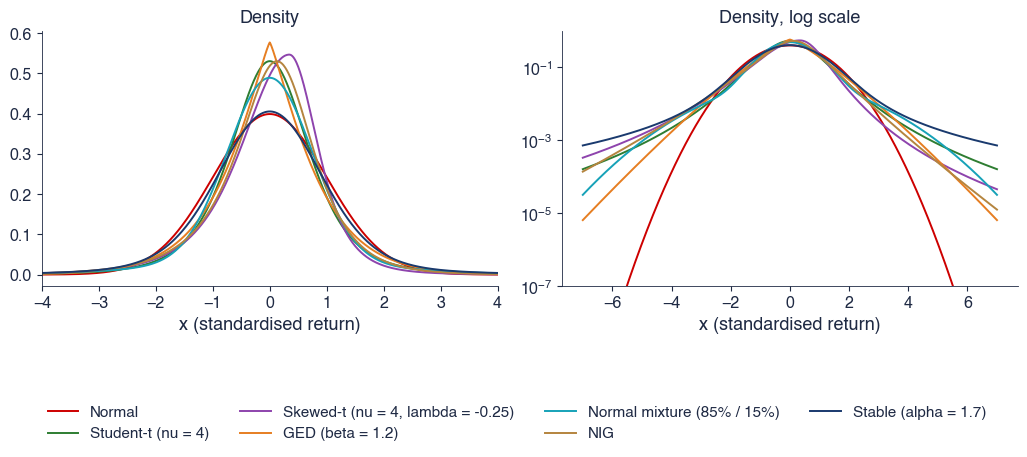

In [7]:
fig_candidates(save=False)

{'book': {'n': 119,
  'min': -0.1934886852121398,
  'max': 0.17119862683754583,
  'mean': 0.0076085867501771,
  'median': 0.016413649414708686,
  'sd': 0.05797884350012888,
  'ann_vol': 0.20084460541261553,
  'skew': -0.8314093276071882,
  'kurt': 4.599890455770624,
  'jb': 26.401217780032958,
  'jb_p': 1.8494747279710667e-06},
 'full': {'n': 267,
  'min': -0.21700051705088264,
  'max': 0.17119862683754583,
  'mean': 0.007135568397775294,
  'median': 0.009328076642850291,
  'sd': 0.053858790208926706,
  'ann_vol': 0.18657232215210848,
  'skew': -0.7157262663080213,
  'kurt': 5.063897822654948,
  'jb': 70.18462765235645,
  'jb_p': 5.749124956363636e-16},
 'book_first': '2004-07-01',
 'book_last': '2014-05-02',
 'full_last': '2026-09-01'}

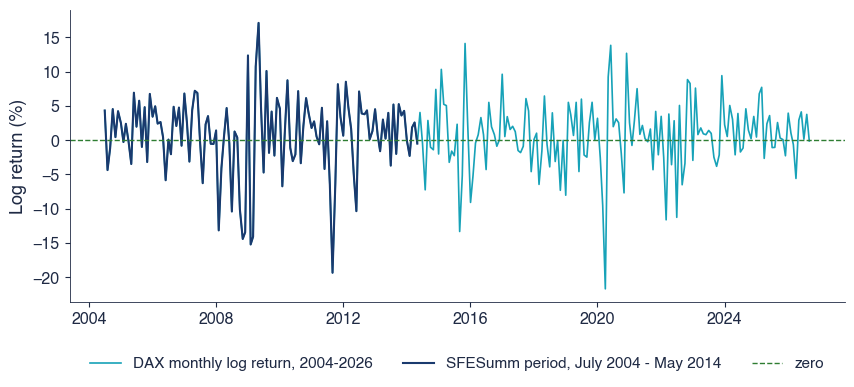

In [8]:
fig_dax_monthly(save=False)

In [9]:
pd.DataFrame(daily_summary()).T[['n', 'mean', 'sd', 'skew', 'kurt', 'jb']].round(3)

,n,mean,sd,skew,kurt,jb
bet,6670,0.063931,1.398639,-0.653293,14.062947,34488.3393
sp500,6714,0.024719,1.21303,-0.348324,13.666118,31961.827305
dax,6786,0.019471,1.40761,-0.165635,9.1028,10561.816792
btc,4384,0.118056,3.485192,-0.704892,14.95772,26482.018755
tlv,3788,0.081326,1.758005,-0.871642,16.519474,29327.833474
snp,3815,0.075697,1.621951,-0.541053,11.919311,12831.921347
brd,3771,0.044392,1.655393,-0.375145,10.260079,8370.313855


In [10]:
tlv_check()

{'r_bad': [-15.008185059343093, 20.53379607141206],
 'raw': {'n': 3790,
  'kurt': 20.482389699836407,
  'nu': 3.3346724004375172,
  'lam': 0.0031367580688009874,
  'aic': {'Normal': 15236.648768922503,
   'Student-t': 14181.213641976374,
   'Skewed-t': 14183.194040409908,
   'GED': 14301.866175668047},
  'best': 'Student-t',
  'var1_emp': 5.110219433135933,
  'var1_t': 4.699253103275146},
 'clean': {'n': 3788,
  'kurt': 16.51947372560188,
  'nu': 3.4362693336983003,
  'lam': 0.0028372436427928287,
  'aic': {'Normal': 15027.101856002024,
   'Student-t': 14139.383090209762,
   'Skewed-t': 14141.366988374077,
   'GED': 14238.894060712228},
  'best': 'Student-t',
  'var1_emp': 5.104648486564502,
  'var1_t': 4.626185573569013}}

## 2. Maximum likelihood fits

- Seven models for seven series (the stable fits take about a minute); the profile log-likelihood of ν.

In [11]:
def fit_all(names=ASSETS + STOCKS, models=MODELS):
    """All candidate fits for each series: parameters, log-likelihood, AIC, BIC, Akaike weights."""
    out = {}
    for k in names:
        r = returns(k)
        x = r.values
        res = {}
        for m in models:
            p = fit_model(m, x)
            ll = p['loglik']
            res[m] = {'params': p, 'loglik': ll, 'k': K[m], 'aic': 2 * K[m] - 2 * ll, 'bic': K[m] * np.log(len(x)) - 2 * ll}
        amin = min(v['aic'] for v in res.values())
        bmin = min(v['bic'] for v in res.values())
        wsum = sum(np.exp(-0.5 * (v['aic'] - amin)) for v in res.values())
        for v in res.values():
            v['daic'] = v['aic'] - amin
            v['dbic'] = v['bic'] - bmin
            v['weight'] = float(np.exp(-0.5 * v['daic']) / wsum)
        out[k] = {'n': len(x), 'first': r.index[0].date().isoformat(), 'last': r.index[-1].date().isoformat(),
                  'models': res, 'best_aic': min(res, key=lambda m: res[m]['aic']), 'best_bic': min(res, key=lambda m: res[m]['bic'])}
        print('  fitted', k, out[k]['best_aic'], out[k]['best_bic'])
    return out


def fits_table(fits):
    rows = []
    for k, f in fits.items():
        for m, v in f['models'].items():
            rows.append({'series': k, 'model': m, 'n': f['n'], 'k': v['k'], 'loglik': v['loglik'], 'aic': v['aic'],
                         'bic': v['bic'], 'daic': v['daic'], 'dbic': v['dbic'], 'weight': v['weight'],
                         **{f'p_{a}': (b if np.isscalar(b) else str(np.round(b, 4).tolist())) for a, b in v['params'].items() if a != 'loglik'}})
    return pd.DataFrame(rows)


def profile_nu(k='sp500', grid=None, save=True):
    """Profile log-likelihood of the Student-t degrees of freedom: for each nu, maximise over location and scale;
    95% interval: all nu with 2 (l_max - l(nu)) <= chi2(1) 95% quantile = 3.84."""
    x = returns(k).values
    grid = grid if grid is not None else np.round(np.arange(2.2, 6.01, 0.1), 2)
    ll = []
    for nu in grid:
        _, loc, sc = stats.t.fit(x, fdf=nu)
        ll.append(np.sum(stats.t.logpdf(x, nu, loc, sc)))
    ll = np.array(ll)
    f = t_fit(x)
    lmax = f['loglik']
    cut = lmax - stats.chi2.ppf(0.95, 1) / 2
    inside = grid[ll >= cut]
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.plot(grid, ll - lmax, color='#1A3A6E', lw=1.6, label='profile log-likelihood l(nu) - l(nu_hat)')
    ax.axhline(cut - lmax, color='#CD0000', ls='--', lw=1.0, label='cut-off -3.84 / 2 (95% interval)')
    ax.axvline(f['nu'], color='#2E7D32', ls=':', lw=1.2, label=f'ML estimate nu_hat = {f["nu"]:.2f}')
    ax.set_ylim(max((ll - lmax).min(), -40), 2)
    ax.set_xlabel('Degrees of freedom nu')
    ax.set_ylabel('Log-likelihood difference')
    st.legend_outside_bottom(ax, ncol=3, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch6_profile_nu')
    return {'nu': f['nu'], 'lo': float(inside.min()), 'hi': float(inside.max()), 'loglik': lmax,
            'll_3': float(np.interp(3.0, grid, ll) - lmax), 'll_5': float(np.interp(5.0, grid, ll) - lmax)}

In [12]:
fits = fit_all()
tab = fits_table(fits)
tab[tab.series == 'sp500'][['model', 'k', 'loglik']]

  fitted bet NIG NIG


  fitted sp500 NIG NIG


  fitted dax NIG NIG


  fitted btc GED GED


  fitted tlv Student-t Student-t


  fitted snp Student-t Student-t


  fitted brd Skewed-t Student-t


,model,k,loglik
7,Normal,2,-10822.867828
8,Student-t,3,-9848.118368
9,Skewed-t,4,-9838.305380
10,GED,3,-9854.248629
11,Mixture,5,-9924.501204
12,NIG,4,-9824.273749
13,Stable,4,-9892.915906


{'nu': 2.6689254297399794,
 'lo': 2.5,
 'hi': 2.8,
 'loglik': -9848.118368097032,
 'll_3': -4.013159713435016,
 'll_5': -92.30327398554073}

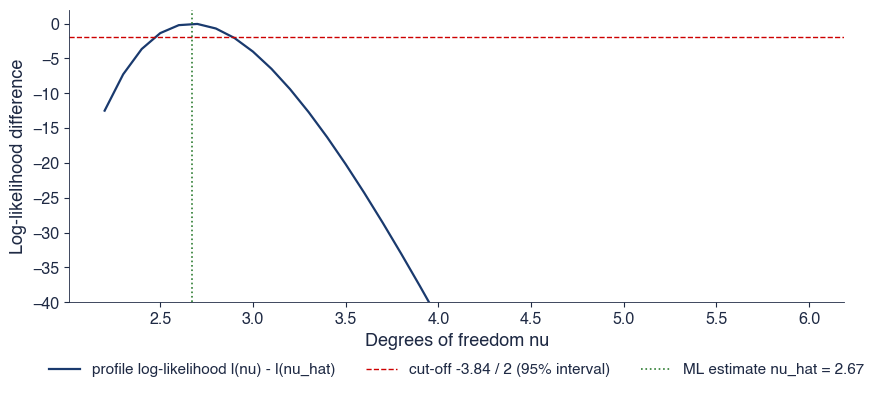

In [13]:
profile_nu('sp500', save=False)

## 3. Likelihood-ratio and Vuong tests, AIC and BIC

- Nested pairs: $LR = 2(\ell_1 - \ell_0) \approx \chi^2(k_1 - k_0)$; on the boundary (Normal inside Student-t): 50:50 mixture.
- Non-nested pairs: Vuong (1989). Information criteria and Akaike weights for every series.

In [14]:
def lr_test(ll0, ll1, df, boundary=False):
    """Likelihood-ratio test of a restricted model (ll0) inside a larger one (ll1): LR = 2 (ll1 - ll0) ~ chi2(df);
    on the boundary of the parameter space (Normal inside Student-t, 1/nu = 0) the null law is the 50:50 mixture of
    chi2(0) and chi2(1) (Self and Liang, 1987)."""
    lr = max(2 * (ll1 - ll0), 0.0)
    p = stats.chi2.sf(lr, df)
    return {'lr': float(lr), 'p': float(0.5 * p if boundary else p)}


def vuong(name1, p1, name2, p2, x):
    """Vuong (1989) test of two non-nested models: V = sqrt(n) mean(m) / sd(m), m_i = log f1(x_i) - log f2(x_i);
    V > 1.96: model 1 closer to the truth (Kullback-Leibler); V < -1.96: model 2; otherwise no decision."""
    m = logpdf(name1, x, p1) - logpdf(name2, x, p2)
    v = np.sqrt(len(m)) * m.mean() / m.std(ddof=1)
    return {'v': float(v), 'p': float(2 * stats.norm.sf(abs(v)))}


def tests_all(fits):
    out = {}
    for k, f in fits.items():
        M = f['models']
        x = returns(k).values
        out[k] = {'t_vs_skt': lr_test(M['Student-t']['loglik'], M['Skewed-t']['loglik'], 1),
                  'n_vs_ged': lr_test(M['Normal']['loglik'], M['GED']['loglik'], 1),
                  'n_vs_t': lr_test(M['Normal']['loglik'], M['Student-t']['loglik'], 1, boundary=True),
                  'vu_t_ged': vuong('Student-t', M['Student-t']['params'], 'GED', M['GED']['params'], x),
                  'vu_skt_nig': vuong('Skewed-t', M['Skewed-t']['params'], 'NIG', M['NIG']['params'], x)}
        if 'Stable' in M:
            out[k]['vu_t_stable'] = vuong('Student-t', M['Student-t']['params'], 'Stable', M['Stable']['params'], x)
    return out


def fig_delta_aic(fits, save=True):
    """Delta AIC of each model relative to the best model, per series (heat map, log colour scale)."""
    from matplotlib.colors import LogNorm
    names = list(fits)
    D = np.array([[fits[k]['models'][m]['daic'] for m in MODELS] for k in names])
    fig, ax = plt.subplots(figsize=(10, 4.0))
    im = ax.imshow(D + 1, cmap='Blues', norm=LogNorm(vmin=1, vmax=max(D.max(), 10) + 1), aspect='auto')
    for i in range(len(names)):
        for j in range(len(MODELS)):
            v = D[i, j]
            txt = '0' if v < 0.5 else f'{v:,.0f}'
            ax.text(j, i, txt, ha='center', va='center', fontsize=10.5,
                    color='white' if v > 300 else 'black', fontweight='bold' if v < 0.5 else 'normal')
    ax.set_xticks(range(len(MODELS)))
    ax.set_xticklabels(['Normal mixture' if m == 'Mixture' else m for m in MODELS])
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels([LABELS[k] for k in names])
    ax.set_title('Delta AIC = AIC - min AIC (0 = best model of the series)')
    cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cb.set_label('Delta AIC + 1 (log scale)')
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch6_delta_aic')

In [15]:
pd.DataFrame({k: {t: round(v['lr'] if 'lr' in v else v['v'], 2) for t, v in d.items()} for k, d in tests_all(fits).items()})

,bet,sp500,dax,btc,tlv,snp,brd
t_vs_skt,0.35,19.63,20.92,0.42,0.02,0.22,3.01
n_vs_ged,2298.11,1937.24,1314.31,1431.46,790.21,602.85,389.49
n_vs_t,2412.81,1949.50,1308.50,1336.89,889.72,680.53,479.97
vu_t_ged,3.70,0.40,-0.23,-3.80,3.62,3.22,3.69
vu_skt_nig,-1.34,-2.20,-2.97,-6.76,1.59,1.16,2.14
vu_t_stable,9.33,6.52,7.66,16.47,3.77,4.16,1.89


In [16]:
tab.pivot(index='series', columns='model', values='daic').round(1)

model,GED,Mixture,NIG,Normal,Skewed-t,Stable,Student-t
series,,,,,,,
bet,129.1,155.8,0.0,2425.2,16.0,106.1,14.4
brd,91.5,32.3,18.8,479.0,0.0,22.8,1.0
btc,0.0,158.6,28.5,1429.5,96.1,196.8,94.6
dax,44.8,129.0,0.0,1357.1,31.7,152.8,50.6
snp,77.7,68.2,12.5,678.5,1.8,42.5,0.0
sp500,57.9,202.5,0.0,1993.2,28.1,137.3,45.7
tlv,99.5,76.8,19.2,887.7,2.0,38.3,0.0


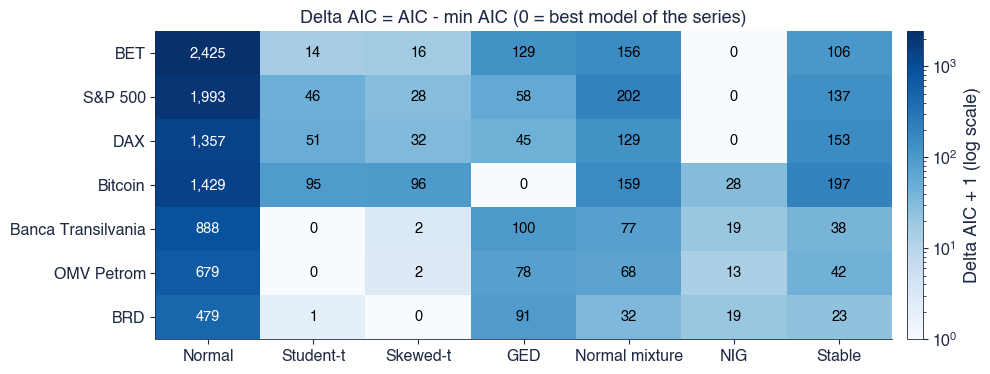

In [17]:
fig_delta_aic(fits, save=False)

## 4. Goodness-of-fit tests

- EDF statistics of every model; parametric bootstrap p-values for the S&P 500 (199 resamples per model, a few minutes); Lilliefors critical values; power of the three tests; where KS and AD look.

In [18]:
def edf_stats(u):
    """Kolmogorov-Smirnov D, Cramer-von Mises W2 and Anderson-Darling A2 from u_i = F(x_i) (F fully specified)."""
    u = np.clip(np.sort(np.asarray(u, float)), 1e-12, 1 - 1e-12)
    n = len(u)
    i = np.arange(1, n + 1)
    d = max(np.max(i / n - u), np.max(u - (i - 1) / n))
    w2 = 1 / (12 * n) + np.sum((u - (2 * i - 1) / (2 * n)) ** 2)
    a2 = -n - np.mean((2 * i - 1) * (np.log(u) + np.log(1 - u[::-1])))
    return {'ks': float(d), 'cvm': float(w2), 'ad': float(a2)}


def gof_bootstrap(name, x, B=199, seed=SEED):
    """EDF statistics of a fitted model and parametric bootstrap p-values: simulate from the fitted model, refit,
    recompute (Stute, Gonzalez Manteiga and Presedo Quindimil, 1993). The naive KS p-value treats the fitted
    parameters as known."""
    x = np.asarray(x, float)
    rng = np.random.default_rng(seed)
    p = fit_model(name, x)
    obs = edf_stats(cdf(name, x, p))
    naive = float(stats.kstwo.sf(obs['ks'], len(x)))
    sims = {s: [] for s in obs}
    for _ in range(B):
        y = ppf(name, rng.uniform(size=len(x)), p) if name != 'Normal' else rng.normal(p['mu'], p['sigma'], len(x))
        q = fit_model(name, y)
        for s, v in edf_stats(cdf(name, y, q)).items():
            sims[s].append(v)
    pv = {s: float((1 + np.sum(np.array(sims[s]) >= obs[s])) / (B + 1)) for s in obs}
    return {'stat': obs, 'p_boot': pv, 'p_naive_ks': naive, 'B': B,
            'crit_boot': {s: float(np.quantile(sims[s], 0.95)) for s in obs}}


def gof_all(fits, names=ASSETS + STOCKS):
    """EDF statistics (no p-values) for every model and series."""
    out = {}
    for k in names:
        x = returns(k).values
        out[k] = {m: edf_stats(cdf(m, x, fits[k]['models'][m]['params'])) for m in fits[k]['models']}
    return out


def lilliefors_crit(n, reps=4000, seed=SEED):
    """95% critical values of KS, CvM and AD for the Normal law with estimated mean and variance (simulation)."""
    rng = np.random.default_rng(seed)
    S = {'ks': [], 'cvm': [], 'ad': []}
    for _ in range(reps):
        y = rng.standard_normal(n)
        for s, v in edf_stats(stats.norm.cdf(y, y.mean(), y.std())).items():
            S[s].append(v)
    return {s: float(np.quantile(v, 0.95)) for s, v in S.items()}


def gof_power(ns=(50, 100, 250, 500, 1000), reps=1000, seed=SEED, save=True):
    """Power of KS, CvM and AD tests of Normality with estimated parameters (5% level, simulated critical values)
    against (left) Student-t data with nu = 5 and (right) a Normal law with 2% of days from a Normal law with
    four times the standard deviation (differences only in the tails)."""
    rng = np.random.default_rng(seed)
    alts = {'t5': lambda n: rng.standard_t(5, n),
            'contam': lambda n: np.where(rng.uniform(size=n) < 0.02, 4.0, 1.0) * rng.standard_normal(n)}
    out = {}
    for a, gen in alts.items():
        out[a] = {}
        for n in ns:
            crit = lilliefors_crit(n, reps=2000, seed=seed + n)
            rej = {'ks': 0, 'cvm': 0, 'ad': 0}
            for _ in range(reps):
                y = gen(n)
                for s, v in edf_stats(stats.norm.cdf(y, y.mean(), y.std())).items():
                    rej[s] += v > crit[s]
            out[a][n] = {s: rej[s] / reps for s in rej}
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.9), sharey=True)
    lab = {'ks': 'Kolmogorov-Smirnov', 'cvm': 'Cramer-von Mises', 'ad': 'Anderson-Darling'}
    col = {'ks': '#CD0000', 'cvm': '#E67E22', 'ad': '#1A3A6E'}
    for ax, a, title in zip(axes, ['t5', 'contam'], ['Student-t data, nu = 5', 'Normal data, 2% of days with 4x volatility']):
        for s in ['ks', 'cvm', 'ad']:
            ax.plot(ns, [out[a][n][s] for n in ns], marker='o', color=col[s], label=lab[s] if a == 't5' else '_')
        ax.axhline(0.05, color='#2E7D32', ls='--', lw=1.0, label='5% level' if a == 't5' else '_')
        ax.set_xscale('log')
        ax.set_xticks(ns)
        ax.set_xticklabels([str(n) for n in ns])
        ax.set_xlabel('Sample size n (log scale)')
        ax.set_title(title)
    axes[0].set_ylabel('Rejection rate of Normality')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch6_gof_power')
    return {a: {str(n): v for n, v in d.items()} for a, d in out.items()}


def fig_ks_tail(k='sp500', save=True):
    """Where do the KS and AD statistics look? F_n(x) - F(x) for the Normal fit, and the same difference divided by
    sqrt(F(1 - F) / n), the weighting behind the Anderson-Darling statistic."""
    x = np.sort(returns(k).values)
    n = len(x)
    mu, sd = x.mean(), x.std()
    F = stats.norm.cdf(x, mu, sd)
    Fn = np.arange(1, n + 1) / n
    d = Fn - F
    Fc = np.clip(F, 1e-8, 1 - 1e-8)                 # model probabilities below 1e-8 are treated as 1e-8
    z = np.sqrt(n) * d / np.sqrt(Fc * (1 - Fc))
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
    axes[0].plot(x, d, color='#1A3A6E', lw=1.2, label='F_n(x) - F(x)')
    i = np.argmax(np.abs(d))
    axes[0].plot(x[i], d[i], 'o', ms=8, color='#CD0000', label=f'KS maximum at x = {x[i]:.2f}%')
    axes[1].plot(x, z, color='#8E44AD', lw=1.0, label='sqrt(n) (F_n - F) / sqrt(F (1 - F))')
    j = np.argmax(np.abs(z))
    axes[1].plot(x[j], z[j], 'o', ms=8, color='#CD0000', label=f'largest weighted gap at x = {x[j]:.2f}%')
    axes[0].set_xlim(-6, 6)
    axes[1].set_xlim(x[0] - 0.5, x[-1] + 0.5)
    axes[1].set_yscale('symlog', linthresh=10)
    axes[1].set_ylabel('Weighted gap (symmetric log scale)')
    axes[0].set_ylabel('Gap')
    for ax, t in zip(axes, ['Unweighted gap (Kolmogorov-Smirnov)', 'Tail-weighted gap (Anderson-Darling weight)']):
        ax.axhline(0, color='#2E7D32', lw=0.9, ls='--', label='_')
        ax.set_xlabel('Daily log return x (%)')
        ax.set_title(t)
        st.legend_outside_bottom(ax, ncol=1, y=-0.18)
    fig.tight_layout()
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch6_ks_tail')
    return {'ks_x': float(x[i]), 'ks_d': float(d[i]), 'ks_F': float(F[i]), 'w_x': float(x[j]), 'w_z': float(z[j]),
            'n': n, 'mu': float(mu), 'sd': float(sd)}

In [19]:
pd.DataFrame(gof_all(fits)['sp500']).T.round(3)

,ks,cvm,ad
Normal,0.093,22.843,127.352
Student-t,0.018,0.568,4.694
Skewed-t,0.017,0.406,2.254
GED,0.019,0.382,3.943
Mixture,0.025,1.089,5.803
NIG,0.010,0.133,0.884
Stable,0.022,0.813,4.608


In [20]:
x = returns('sp500').values
{m: gof_bootstrap(m, x, B=199)['p_boot'] for m in ['Normal', 'Student-t', 'Skewed-t']}

{'Normal': {'ks': 0.005, 'cvm': 0.005, 'ad': 0.005},
 'Student-t': {'ks': 0.005, 'cvm': 0.005, 'ad': 0.005},
 'Skewed-t': {'ks': 0.005, 'cvm': 0.005, 'ad': 0.005}}

In [21]:
pd.DataFrame({n: lilliefors_crit(n) for n in (5, 100, 1000)}).round(3)

,5,100,1000
ks,0.351,0.090,0.029
cvm,0.115,0.130,0.127
ad,0.666,0.781,0.756


{'t5': {'50': {'ks': 0.209, 'cvm': 0.238, 'ad': 0.272},
  '100': {'ks': 0.297, 'cvm': 0.42, 'ad': 0.48},
  '250': {'ks': 0.623, 'cvm': 0.766, 'ad': 0.813},
  '500': {'ks': 0.896, 'cvm': 0.956, 'ad': 0.973},
  '1000': {'ks': 0.999, 'cvm': 1.0, 'ad': 1.0}},
 'contam': {'50': {'ks': 0.173, 'cvm': 0.199, 'ad': 0.221},
  '100': {'ks': 0.234, 'cvm': 0.286, 'ad': 0.332},
  '250': {'ks': 0.38, 'cvm': 0.497, 'ad': 0.574},
  '500': {'ks': 0.604, 'cvm': 0.715, 'ad': 0.793},
  '1000': {'ks': 0.825, 'cvm': 0.92, 'ad': 0.956}}}

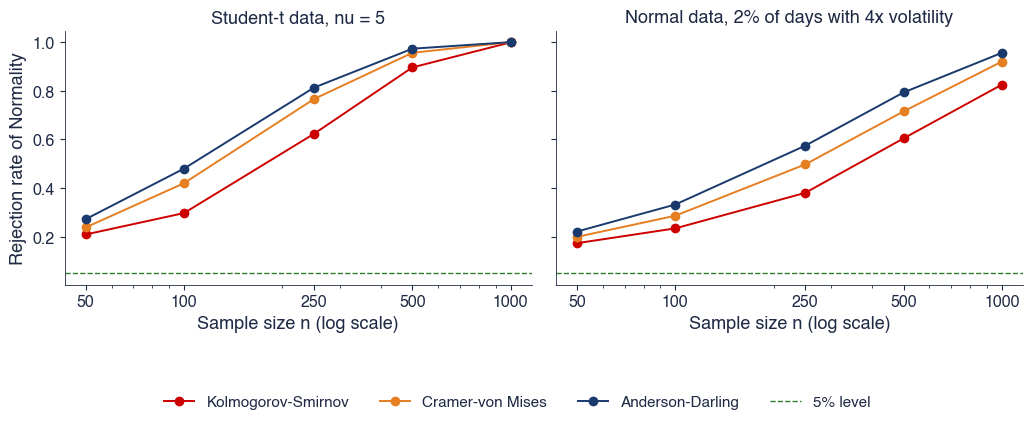

In [22]:
gof_power(save=False)

{'ks_x': -0.41499040607870796,
 'ks_d': -0.09321686575149774,
 'ks_F': 0.3584834728411611,
 'w_x': -6.895833042745458,
 'w_z': 1098.373294770194,
 'n': 6714,
 'mu': 0.024718705886760825,
 'sd': 1.212939250854622}

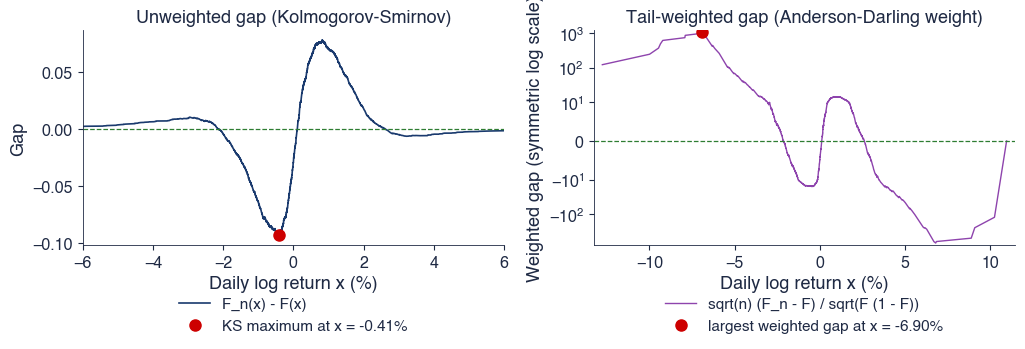

In [23]:
fig_ks_tail('sp500', save=False)

## 5. PP and QQ plots

In [24]:
def fig_pp_qq(fits, k='sp500', save=True):
    """PP plots (model probability vs empirical probability) and QQ plots (empirical vs model quantiles) of the
    Normal, Student-t, skewed-t and stable fits."""
    x = np.sort(returns(k).values)
    n = len(x)
    pe = (np.arange(1, n + 1) - 0.5) / n
    sel = np.unique(np.concatenate([np.linspace(0, n - 1, 400).astype(int), np.arange(30), np.arange(n - 30, n)]))
    out = {}
    fig, axes = plt.subplots(1, 4, figsize=(11, 3.3), sharex=True, sharey=True)
    for ax, m in zip(axes, PANEL):
        p = fits[k]['models'][m]['params']
        u = cdf(m, x, p)
        ax.plot(pe[sel], u[sel], '.', ms=3, color=MODEL_COL[m], label=m)
        ax.plot([0, 1], [0, 1], color='black', lw=0.8, ls='--', label='45-degree line' if m == PANEL[-1] else '_')
        ax.set_title(m)
        ax.set_xlabel('Empirical probability')
        out[m] = {'pp_maxdev': float(np.max(np.abs(u - pe)))}
    axes[0].set_ylabel('Model probability F(x)')
    fig.legend(*zip(*[(h, l) for ax in axes for h, l in zip(*ax.get_legend_handles_labels())]), loc='upper center',
               bbox_to_anchor=(0.5, 0.0), ncol=5, frameon=False, markerscale=4)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch6_pp')
    fig, axes = plt.subplots(1, 4, figsize=(11, 3.4), sharey=True)
    for ax, m in zip(axes, PANEL):
        p = fits[k]['models'][m]['params']
        q = ppf(m, pe[sel], p)
        ax.plot(q, x[sel], '.', ms=3.5, color=MODEL_COL[m], label=m)
        lim = [x[0], x[-1]]
        ax.plot(lim, lim, color='black', lw=0.8, ls='--', label='45-degree line' if m == PANEL[-1] else '_')
        ax.set_xlim(min(q.min(), x[0]) * 1.05, max(q.max(), x[-1]) * 1.05)
        ax.set_title(m)
        ax.set_xlabel('Model quantile (%)')
        out[m]['q0001'] = float(ppf(m, 0.5 / n, p))
    axes[0].set_ylabel('Empirical quantile (%)')
    fig.legend(*zip(*[(h, l) for ax in axes for h, l in zip(*ax.get_legend_handles_labels())]), loc='upper center',
               bbox_to_anchor=(0.5, 0.0), ncol=5, frameon=False, markerscale=4)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch6_qq')
    out['x_min'] = float(x[0])
    out['x_max'] = float(x[-1])
    out['n'] = n
    return out


def fig_qq_assets(fits, names=('bet', 'btc', 'tlv'), models=('Normal', 'Student-t', 'Skewed-t'), save=True):
    """QQ plots of three more series against the Normal, Student-t and skewed-t fits (one panel per series)."""
    fig, axes = plt.subplots(1, len(names), figsize=(11, 3.6))
    for ax, k in zip(axes, names):
        x = np.sort(returns(k).values)
        n = len(x)
        pe = (np.arange(1, n + 1) - 0.5) / n
        sel = np.unique(np.concatenate([np.linspace(0, n - 1, 300).astype(int), np.arange(25), np.arange(n - 25, n)]))
        for m in models:
            q = ppf(m, pe[sel], fits[k]['models'][m]['params'])
            ax.plot(q, x[sel], '.', ms=3.2, color=MODEL_COL[m], label=m if k == names[0] else '_')
        ax.plot([x[0], x[-1]], [x[0], x[-1]], color='black', lw=0.8, ls='--', label='45-degree line' if k == names[0] else '_')
        ax.set_title(LABELS[k])
        ax.set_xlabel('Model quantile (%)')
    axes[0].set_ylabel('Empirical quantile (%)')
    fig.legend(*axes[0].get_legend_handles_labels(), loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=4, frameon=False, markerscale=4)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch6_qq_assets')

{'Normal': {'pp_maxdev': 0.09329133700559367, 'q0001': -4.575748854474584},
 'Student-t': {'pp_maxdev': 0.018299768171467654, 'q0001': -22.9432792967861},
 'Skewed-t': {'pp_maxdev': 0.016644353704476478, 'q0001': -24.481492143723443},
 'Stable': {'pp_maxdev': 0.022178922367283083, 'q0001': -116.13321421440719},
 'x_min': -12.76521830653392,
 'x_max': 10.957195934756658,
 'n': 6714}

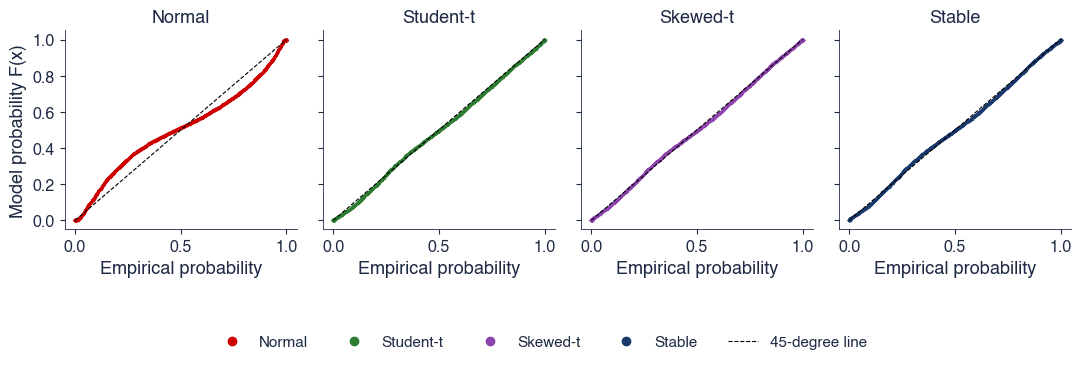

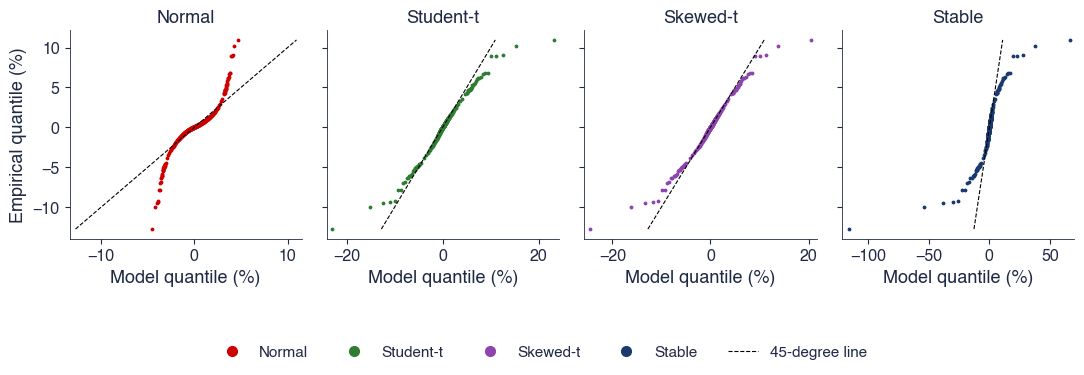

In [25]:
fig_pp_qq(fits, 'sp500', save=False)

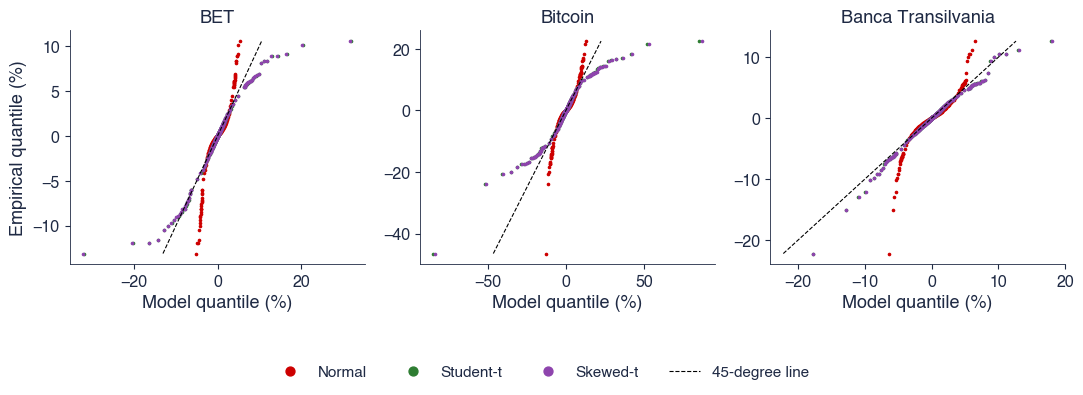

In [26]:
fig_qq_assets(fits, save=False)

## 6. Tails: VaR 1%, ES 2.5% and exceedances

- The Kupiec (1995) test: $LR_{uc} = -2\ln[(1-p)^{n-x}p^x / ((1-x/n)^{n-x}(x/n)^x)] \approx \chi^2(1)$.

In [27]:
def kupiec(x, n, p=ALPHA_VAR):
    """Kupiec (1995) unconditional coverage test: LR = -2 ln[(1-p)^(n-x) p^x / ((1-x/n)^(n-x) (x/n)^x)] ~ chi2(1)."""
    phat = x / n
    l0 = (n - x) * np.log(1 - p) + x * np.log(p)
    l1 = (n - x) * np.log(1 - phat) + (x * np.log(phat) if x > 0 else 0.0)
    lr = -2 * (l0 - l1)
    return {'x': int(x), 'n': int(n), 'rate': float(phat), 'lr': float(lr), 'p': float(stats.chi2.sf(lr, 1))}


def tail_table(fits, names=ASSETS + STOCKS):
    """VaR 1% and ES 2.5% of the data and of each model; in-sample exceedances of each model's VaR 1%."""
    out = {}
    for k in names:
        x = returns(k).values
        q = np.quantile(x, ALPHA_VAR)
        qe = np.quantile(x, ALPHA_ES)
        row = {'emp': {'var1': float(-q), 'es25': float(-x[x <= qe].mean())}}
        for m, v in fits[k]['models'].items():
            var, es = var_es(m, v['params'])
            row[m] = {'var1': var, 'es25': es, 'kupiec': kupiec(int(np.sum(x < -var)), len(x))}
        out[k] = row
    return out


def fig_left_tail(fits, k='sp500', models=('Normal', 'Student-t', 'Skewed-t', 'NIG', 'Stable'), save=True):
    """The left tail on log-log axes: share of days with a loss above x, against the same probability under each model."""
    x = returns(k).values
    L = np.sort(-x)[::-1]
    n = len(x)
    emp = np.arange(1, n + 1) / n
    sel = L > 0.5
    grid = np.logspace(np.log10(0.5), np.log10(L.max() * 1.6), 80)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.loglog(L[sel], emp[sel], '.', ms=4, color=MODEL_COL['Data'], label='data')
    for m in models:
        p = fits[k]['models'][m]['params']
        ax.loglog(grid, np.clip(cdf(m, -grid, p), 1e-9, None), color=MODEL_COL[m], lw=1.5, label=m)
    ax.axhline(ALPHA_VAR, color='#2E7D32', lw=0.9, ls=':', label='_')
    ax.text(grid[1], ALPHA_VAR * 1.25, '1% (VaR 1%)', color='#2E7D32', fontsize=10.5)
    ax.set_ylim(0.5 / n, 0.6)
    ax.set_xlabel('Daily loss x (%, log scale)')
    ax.set_ylabel('P(loss > x) (log scale)')
    st.legend_outside_bottom(ax, ncol=6, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch6_left_tail')


def fig_var_models(tails, names=ASSETS + STOCKS, models=('Normal', 'Student-t', 'Skewed-t', 'GED', 'NIG', 'Stable'), save=True):
    """VaR 1% of each model divided by the empirical VaR 1% (1 = exact in sample)."""
    fig, ax = plt.subplots(figsize=(10.5, 3.9))
    w = 0.8 / len(models)
    xs = np.arange(len(names))
    for j, m in enumerate(models):
        ax.bar(xs + (j - (len(models) - 1) / 2) * w, [tails[k][m]['var1'] / tails[k]['emp']['var1'] for k in names],
               width=w, color=MODEL_COL[m], label=m)
    ax.axhline(1, color='black', lw=0.9, ls='--', label='empirical VaR 1%')
    ax.set_xticks(xs)
    ax.set_xticklabels([SHORT[k] for k in names])
    ax.set_ylabel('Model VaR 1% / empirical VaR 1%')
    ax.set_ylim(0.6, None)
    st.legend_outside_bottom(ax, ncol=7, y=-0.14)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch6_var_models')

In [28]:
tails = tail_table(fits)
pd.DataFrame({k: {m: round(v['var1'], 2) for m, v in t.items()} for k, t in tails.items()})

,bet,sp500,dax,btc,tlv,snp,brd
emp,4.13,3.45,4.16,10.51,5.10,4.29,4.50
Normal,3.19,2.80,3.25,7.99,4.01,3.70,3.81
Student-t,4.06,3.46,3.96,11.06,4.63,4.26,4.24
Skewed-t,4.10,3.71,4.24,10.91,4.61,4.22,4.39
GED,3.74,3.27,3.77,9.85,4.49,4.16,4.18
Mixture,4.53,3.97,4.35,10.40,5.41,4.70,4.74
NIG,4.11,3.72,4.24,10.52,4.76,4.32,4.43
Stable,4.94,4.54,5.01,14.26,4.92,4.43,4.51


In [29]:
pd.DataFrame({k: {m: v['kupiec']['x'] for m, v in t.items() if m != 'emp'} for k, t in tails.items()})

,bet,sp500,dax,btc,tlv,snp,brd
Normal,138,131,145,86,59,57,60
Student-t,71,67,78,34,46,40,50
Skewed-t,69,52,66,36,47,40,41
GED,91,80,91,56,49,41,52
Mixture,52,45,59,48,30,30,29
NIG,68,52,65,44,43,38,40
Stable,43,30,39,16,41,35,38


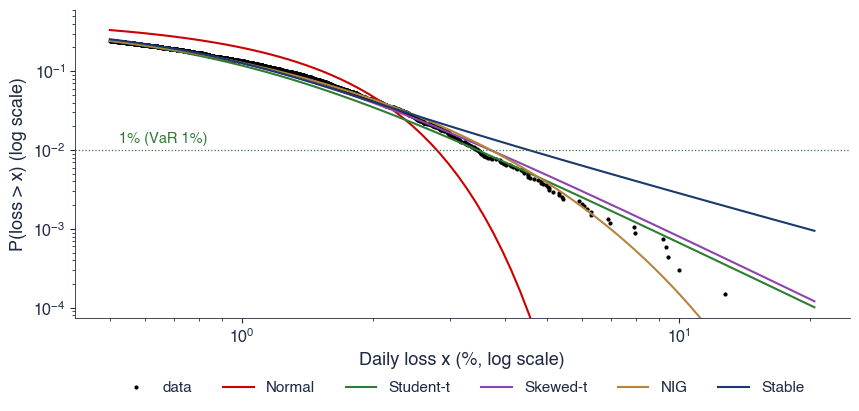

In [30]:
fig_left_tail(fits, 'sp500', save=False)

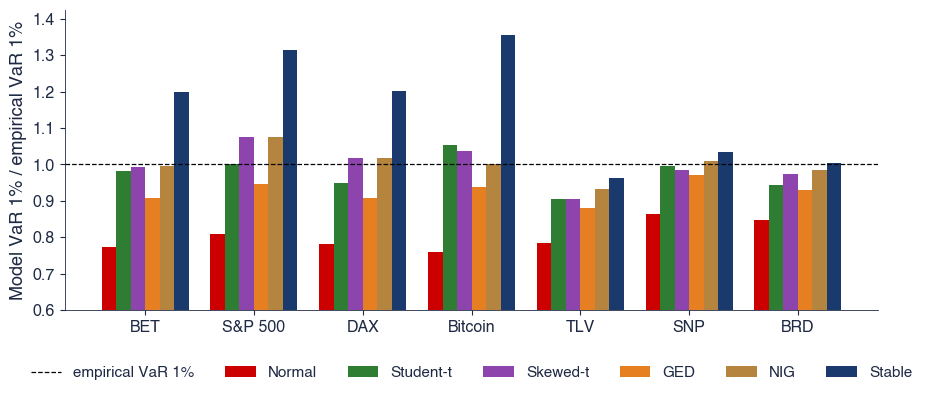

In [31]:
fig_var_models(tails, save=False)

## 7. Out of sample, overfitting, rolling VaR

- Estimation until 31 December 2019, test 2020–2026; Normal mixtures with 1–6 components; a rolling 1000-day window refitted every 20 days; the VaR reliability plot of the Quantlet SFEVaRqqplot.

In [32]:
def pinball(r, q, a=ALPHA_VAR):
    """Quantile (pinball) loss of a VaR forecast q (a quantile of the return): mean of (a - 1{r < q})(r - q)."""
    r = np.asarray(r, float)
    return float(np.mean((a - (r < q)) * (r - q)))


def out_of_sample(names=ASSETS, models=MODELS, split=SPLIT):
    """Fit each model until `split`; on the later days: mean log score, VaR 1% exceedances (Kupiec) and pinball loss."""
    out = {}
    for k in names:
        r = returns(k)
        est, test = r.loc[:split].values, r.loc[split:].iloc[1:].values
        row = {'n_est': len(est), 'n_test': len(test), 'emp_var1_est': float(-np.quantile(est, ALPHA_VAR))}
        for m in models:
            p = fit_model(m, est)
            q = float(np.ravel(ppf(m, ALPHA_VAR, p))[0])
            ls = logpdf(m, test, p)
            row[m] = {'logscore': float(np.mean(ls)), 'loglik_in': p['loglik'] / len(est), 'aic': 2 * K[m] - 2 * p['loglik'],
                      'var1': -q, 'kupiec': kupiec(int(np.sum(test < q)), len(test)), 'pinball': pinball(test, q)}
        qh = np.quantile(est, ALPHA_VAR)
        row['Historical'] = {'var1': float(-qh), 'kupiec': kupiec(int(np.sum(test < qh)), len(test)), 'pinball': pinball(test, qh)}
        aics = {m: row[m]['aic'] for m in models}
        row['best_aic_est'] = min(aics, key=aics.get)
        row['best_logscore'] = max(models, key=lambda m: row[m]['logscore'])
        row['best_pinball'] = min(list(models) + ['Historical'], key=lambda m: row[m]['pinball'])
        out[k] = row
        print('  oos', k, row['best_aic_est'], row['best_logscore'], row['best_pinball'])
    return out


def fig_oos(oos, names=ASSETS, models=('Normal', 'Student-t', 'Skewed-t', 'GED', 'Mixture', 'NIG', 'Stable'), save=True):
    """Left: out-of-sample mean log score minus that of the Normal model. Right: VaR 1% exceedance rate on the test days."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
    w = 0.8 / len(models)
    xs = np.arange(len(names))
    for j, m in enumerate(models):
        off = (j - (len(models) - 1) / 2) * w
        axes[0].bar(xs + off, [oos[k][m]['logscore'] - oos[k]['Normal']['logscore'] for k in names], width=w, color=MODEL_COL[m], label=m)
        axes[1].bar(xs + off, [100 * oos[k][m]['kupiec']['rate'] for k in names], width=w, color=MODEL_COL[m], label='_')
    axes[1].axhline(1, color='black', lw=0.9, ls='--', label='target 1%')
    axes[0].set_title('Out-of-sample log score minus Normal')
    axes[1].set_title('VaR 1% exceedances on the test days (%)')
    for ax in axes:
        ax.set_xticks(xs)
        ax.set_xticklabels([LABELS[k] for k in names])
    st.fig_legend_bottom(fig, ncol=8, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch6_oos')


def overfit_mixtures(k='sp500', est=('2017-01-01', '2018-12-31'), test_end=None, kmax=6, save=True):
    """Overfitting: Normal mixtures with 1-6 components fitted on two years of returns; in-sample log-likelihood,
    AIC, BIC and the out-of-sample mean log score on the following years."""
    r = returns(k)
    x = r.loc[est[0]:est[1]].values
    y = r.loc[est[1]:].iloc[1:].values if test_end is None else r.loc[est[1]:test_end].iloc[1:].values
    out = {}
    for c in range(1, kmax + 1):
        p = mixture_em(x, c, starts=12, seed=SEED + c)
        kk = 3 * c - 1
        out[c] = {'k': kk, 'loglik': p['loglik'], 'aic': 2 * kk - 2 * p['loglik'], 'bic': kk * np.log(len(x)) - 2 * p['loglik'],
                  'in': p['loglik'] / len(x), 'out': float(np.mean(mixture_logpdf(y, p['w'], p['mu'], p['sd'])))}
    cs = list(out)
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
    axes[0].plot(cs, [out[c]['in'] for c in cs], 'o-', color='#1A3A6E', label='in sample (estimation years)')
    axes[0].plot(cs, [out[c]['out'] for c in cs], 's-', color='#CD0000', label='out of sample (later years)')
    axes[0].set_title('Mean log-likelihood per day')
    axes[1].plot(cs, [out[c]['aic'] - min(out[d]['aic'] for d in cs) for c in cs], 'o-', color='#2E7D32', label='Delta AIC')
    axes[1].plot(cs, [out[c]['bic'] - min(out[d]['bic'] for d in cs) for c in cs], 's-', color='#8E44AD', label='Delta BIC')
    axes[1].set_title('Information criteria (0 = selected)')
    for ax in axes:
        ax.set_xlabel('Number of Normal components')
        ax.set_xticks(cs)
        st.legend_outside_bottom(ax, ncol=2, y=-0.18)
    fig.tight_layout()
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch6_overfit')
    return {'n_in': len(x), 'n_out': len(y), 'est': list(est),
            'res': {str(c): v for c, v in out.items()},
            'best_in': max(cs, key=lambda c: out[c]['in']), 'best_out': max(cs, key=lambda c: out[c]['out']),
            'best_aic': min(cs, key=lambda c: out[c]['aic']), 'best_bic': min(cs, key=lambda c: out[c]['bic'])}


def rolling_var(k='sp500', window=1000, step=20, models=('Normal', 'Student-t', 'Skewed-t')):
    """Rolling VaR 1%: each model refitted every `step` days on the previous `window` days; historical simulation
    (empirical 1% quantile of the window) as a benchmark."""
    r = returns(k)
    x = r.values
    idx = r.index
    V = {m: np.full(len(x), np.nan) for m in list(models) + ['Historical']}
    for s in range(window, len(x), step):
        w = x[s - window:s]
        for m in models:
            V[m][s:s + step] = np.ravel(ppf(m, ALPHA_VAR, fit_model(m, w)))[0]
        V['Historical'][s:s + step] = np.quantile(w, ALPHA_VAR)
    df = pd.DataFrame(V, index=idx)
    df['r'] = x
    df = df.iloc[window:]
    res = {m: kupiec(int(np.sum(df['r'] < df[m])), len(df)) for m in V}
    for m in V:
        e = (df['r'] < df[m]).astype(int)
        res[m]['max_year'] = int(e.groupby(df.index.year).sum().max())
        res[m]['max_year_y'] = int(e.groupby(df.index.year).sum().idxmax())
    res['first'] = df.index[0].date().isoformat()
    return df, res


def fig_rolling_var(df, k='sp500', since='2018-01-01', save=True):
    d = df.loc[since:]
    fig, ax = plt.subplots(figsize=(10.5, 3.9))
    ax.plot(d.index, d['r'], color='#17A2B8', lw=0.6, label=f'{LABELS[k]} daily log return (%)')
    for m, c in [('Normal', MODEL_COL['Normal']), ('Student-t', MODEL_COL['Student-t']), ('Historical', '#8E44AD')]:
        ax.plot(d.index, d[m], color=c, lw=1.3, label=f'VaR 1% line, {m}' if m != 'Historical' else 'VaR 1% line, historical simulation')
    e = d['r'] < d['Student-t']
    ax.plot(d.index[e], d['r'][e], 'v', ms=5, color='black', label='exceedance of the Student-t VaR 1%')
    ax.set_ylabel('%')
    st.legend_outside_bottom(ax, ncol=3, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch6_rolling_var')


def var_rma_ema(y, h=250, lam=0.96, a=ALPHA_VAR):
    """VaR of the Quantlet SFEVaRqqplot: Normal VaR with the volatility from a rectangular moving average (RMA) of the
    previous h squared returns, or an exponential moving average (EMA, weight lam^j on the return j + 1 days back,
    normalised by 1 - lam)."""
    y = np.asarray(y, float)
    n = len(y)
    c = np.concatenate([[0.0], np.cumsum(y ** 2)])
    rma = np.sqrt((c[h:n] - c[:n - h]) / h)                       # days h+1..n: mean of the previous h squares
    wts = lam ** np.arange(h)[::-1]
    ema = np.sqrt((1 - lam) * np.array([np.sum(wts * y[j - h:j] ** 2) for j in range(h, n)]))
    z = stats.norm.ppf(a)
    return z * rma, z * ema


def fig_var_qqplot(k='dax', h=250, lam=0.96, save=True):
    """VaR reliability plot (SFEVaRqqplot): QQ plot of the return divided by the VaR forecast, L/VaR, against the
    Normal quantiles, for the RMA and EMA volatility models; a straight line means a well-specified VaR model."""
    r = returns(k)
    y = r.values / 100
    v_rma, v_ema = var_rma_ema(y, h, lam)
    p = y[h:]
    out = {'n': len(p), 'first': r.index[h].date().isoformat()}
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), sharey=True)
    for ax, v, name, c in [(axes[0], v_rma, 'RMA, h = 250', '#1A3A6E'), (axes[1], v_ema, 'EMA, lambda = 0.96', '#E67E22')]:
        ratio = np.sort(p / v)
        qn = stats.norm.ppf((np.arange(1, len(ratio) + 1) - 0.5) / len(ratio))
        ax.plot(qn, ratio, '.', ms=2.5, color=c, label=f'L/VaR, {name}')
        b = np.quantile(ratio, [0.25, 0.75])
        qb = stats.norm.ppf([0.25, 0.75])
        sl = (b[1] - b[0]) / (qb[1] - qb[0])
        ax.plot(qn, b[0] + sl * (qn - qb[0]), color='black', lw=0.9, ls='--', label='line through the quartiles')
        ax.set_title(name)
        ax.set_xlabel('Normal quantiles')
        st.legend_outside_bottom(ax, ncol=1, y=-0.18)
        key = 'rma' if 'RMA' in name else 'ema'
        ex = np.sum(p < v)
        out[key] = dict(kupiec(int(ex), len(p)), kurt_std=float(stats.kurtosis(p / v * stats.norm.ppf(ALPHA_VAR), fisher=False)),
                        min_ratio=float(ratio[0]), max_ratio=float(ratio[-1]))
    axes[0].set_ylabel('L/VaR quantiles')
    fig.tight_layout()
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch6_var_qqplot')
    return out

In [33]:
oos = out_of_sample()
pd.DataFrame({k: {m: (round(v['logscore'], 4) if 'logscore' in v else None, v['kupiec']['x']) for m, v in o.items() if isinstance(v, dict)} for k, o in oos.items()})

  oos bet NIG Student-t Normal


  oos sp500 NIG Skewed-t Student-t


  oos dax NIG NIG GED


  oos btc GED NIG Normal


,bet,sp500,dax,btc
Normal,"(-1.5648, 17)","(-1.6704, 38)","(-1.6679, 27)","(-2.6047, 23)"
Student-t,"(-1.3597, 5)","(-1.4978, 19)","(-1.5332, 11)","(-2.4428, 7)"
Skewed-t,"(-1.3604, 5)","(-1.497, 14)","(-1.5316, 8)","(-2.4425, 7)"
GED,"(-1.3759, 8)","(-1.5115, 24)","(-1.5394, 18)","(-2.4431, 10)"
Mixture,"(-1.3706, 4)","(-1.5227, 14)","(-1.5422, 8)","(-2.462, 10)"
NIG,"(-1.3608, 5)","(-1.5003, 14)","(-1.5299, 8)","(-2.4383, 7)"
Stable,"(-1.3651, 3)","(-1.5015, 8)","(-1.5399, 4)","(-2.4543, 1)"
Historical,"(None, 5)","(None, 23)","(None, 8)","(None, 10)"


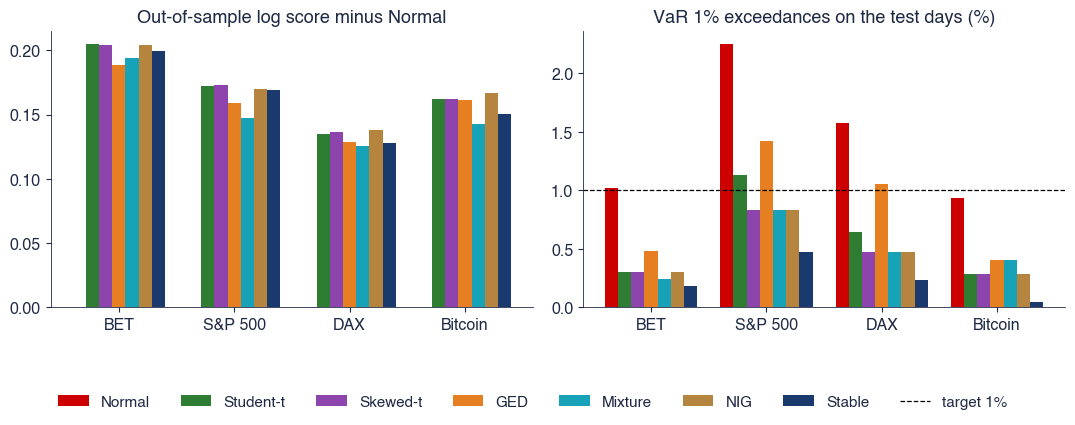

In [34]:
fig_oos(oos, save=False)

,k,loglik,aic,bic,in,out
1,2.0,-610.500,1224.999,1233.433,-1.219,-1.841
2,5.0,-518.095,1046.191,1067.274,-1.034,-1.615
3,8.0,-500.738,1017.477,1051.209,-0.999,-1.608
4,11.0,-492.166,1006.333,1052.716,-0.982,-1.635
5,14.0,-487.730,1003.459,1062.492,-0.974,-1.645
6,17.0,-486.584,1007.168,1078.850,-0.971,-1.698


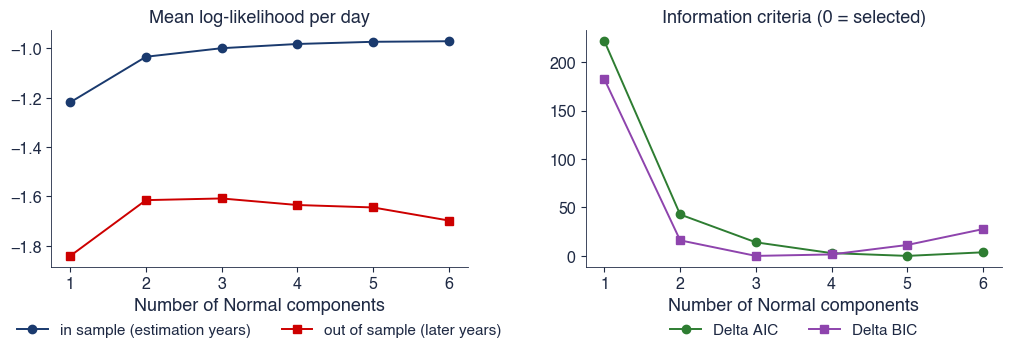

In [35]:
of = overfit_mixtures('sp500', save=False)
pd.DataFrame(of['res']).T.round(3)

,x,n,rate,lr,p,max_year,max_year_y
Normal,134.0,5714.0,0.023451,75.754950,3.211450e-18,36.0,2008.0
Student-t,89.0,5714.0,0.015576,15.337268,8.992491e-05,31.0,2008.0
Skewed-t,84.0,5714.0,0.014701,11.140223,8.447574e-04,28.0,2008.0
Historical,90.0,5714.0,0.015751,16.246200,5.562105e-05,29.0,2008.0


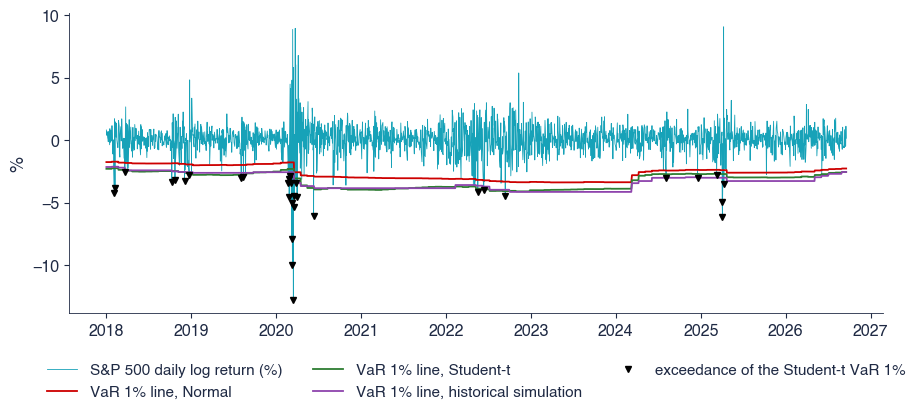

In [36]:
df, res = rolling_var('sp500')
fig_rolling_var(df, 'sp500', save=False)
pd.DataFrame({m: v for m, v in res.items() if m != 'first'}).T

{'n': 6536,
 'first': '2000-12-27',
 'rma': {'x': 139,
  'n': 6536,
  'rate': 0.021266829865361075,
  'lr': 63.32991568100647,
  'p': 1.7482889183909644e-15,
  'kurt_std': 8.836990222020129,
  'min_ratio': -2.993922243566735,
  'max_ratio': 4.985958367321731},
 'ema': {'x': 135,
  'n': 6536,
  'rate': 0.02065483476132191,
  'lr': 57.32056957484065,
  'p': 3.7026253202908265e-14,
  'kurt_std': 5.0365230411723925,
  'min_ratio': -2.5604376129622537,
  'max_ratio': 3.1906120445242694}}

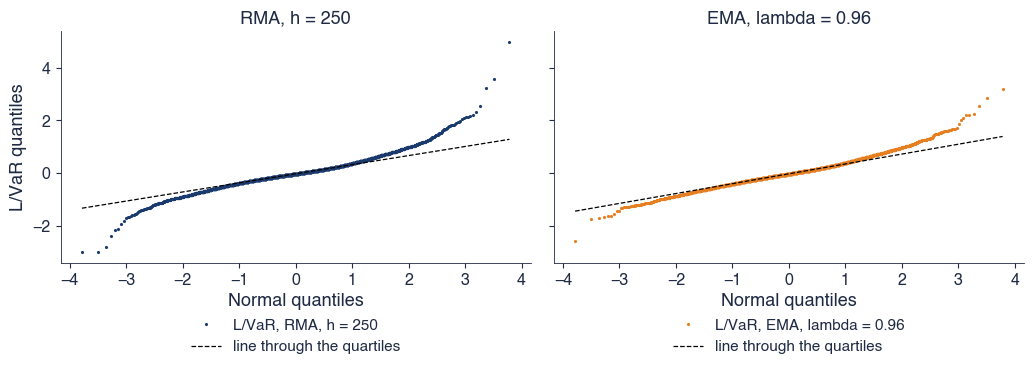

In [37]:
fig_var_qqplot('dax', save=False)

## 8. Model uncertainty

- Moving-block bootstrap of the AIC winner and of VaR 1% (200 resamples, several minutes); VaR averaged with the Akaike weights.

In [38]:
def block_bootstrap(x, block=BLOCK, rng=None):
    """Moving-block bootstrap resample of the same length (blocks of consecutive days keep volatility clusters)."""
    n = len(x)
    starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
    return np.concatenate([x[s:s + block] for s in starts])[:n]


def model_uncertainty(k='sp500', B=200, models=('Normal', 'Student-t', 'Skewed-t', 'GED', 'Mixture', 'NIG'), seed=SEED, save=True):
    """Moving-block bootstrap: share of resamples in which each model has the lowest AIC, and the bootstrap spread
    of VaR 1% under each model."""
    x = returns(k).values
    rng = np.random.default_rng(seed)
    wins = {m: 0 for m in models}
    var = {m: [] for m in models}
    for b in range(B):
        y = block_bootstrap(x, rng=rng)
        aic = {}
        for m in models:
            p = fit_model(m, y)
            aic[m] = 2 * K[m] - 2 * p['loglik']
            var[m].append(-float(np.ravel(ppf(m, ALPHA_VAR, p))[0]))
        wins[min(aic, key=aic.get)] += 1
        if (b + 1) % 50 == 0:
            print('   bootstrap', b + 1)
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.9))
    axes[0].bar(range(len(models)), [100 * wins[m] / B for m in models], color=[MODEL_COL[m] for m in models])
    axes[0].set_xticks(range(len(models)))
    axes[0].set_xticklabels(['Mixture' if m == 'Mixture' else m for m in models], rotation=20)
    axes[0].set_ylabel('% of resamples with the lowest AIC')
    axes[0].set_title('Which model wins?')
    bp = axes[1].boxplot([var[m] for m in models], patch_artist=True, widths=0.55)
    for patch, m in zip(bp['boxes'], models):
        patch.set_facecolor(MODEL_COL[m])
        patch.set_alpha(0.6)
        patch.set_edgecolor('black')
    for el in ('whiskers', 'caps', 'medians'):
        for line in bp[el]:
            line.set_color('black')
    for fl in bp['fliers']:
        fl.set_markeredgecolor('#CD0000')
    emp = -np.quantile(x, ALPHA_VAR)
    axes[1].axhline(emp, color='#CD0000', ls='--', lw=1.0, label=f'empirical VaR 1% = {emp:.2f}%')
    axes[1].set_xticks(range(1, len(models) + 1))
    axes[1].set_xticklabels(models, rotation=20)
    axes[1].set_ylabel('VaR 1% (%)')
    axes[1].set_title('Bootstrap spread of VaR 1%')
    st.legend_outside_bottom(axes[1], ncol=1, y=-0.25)
    fig.tight_layout()
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch6_model_uncertainty')
    return {'B': B, 'wins': {m: wins[m] / B for m in models},
            'var': {m: {'median': float(np.median(v)), 'q05': float(np.quantile(v, 0.05)), 'q95': float(np.quantile(v, 0.95))} for m, v in var.items()},
            'emp_var1': float(emp)}


def averaged_var(fits, tails, names=ASSETS + STOCKS):
    """VaR 1% averaged over the models with the Akaike weights, and the range of VaR 1% across the models."""
    out = {}
    for k in names:
        M = fits[k]['models']
        avg = sum(M[m]['weight'] * tails[k][m]['var1'] for m in M)
        vs = [tails[k][m]['var1'] for m in M if m != 'Normal']
        out[k] = {'avg': float(avg), 'min_heavy': float(min(vs)), 'max_heavy': float(max(vs)), 'normal': tails[k]['Normal']['var1'],
                  'emp': tails[k]['emp']['var1']}
    return out

   bootstrap 50


   bootstrap 100


   bootstrap 150


   bootstrap 200


{'B': 200,
 'wins': {'Normal': 0.0,
  'Student-t': 0.0,
  'Skewed-t': 0.03,
  'GED': 0.035,
  'Mixture': 0.0,
  'NIG': 0.935},
 'var': {'Normal': {'median': 2.7897557166725475,
   'q05': 2.564634699572039,
   'q95': 3.0654020177172416},
  'Student-t': {'median': 3.4658999126236054,
   'q05': 3.136839827845447,
   'q95': 3.8695305766815604},
  'Skewed-t': {'median': 3.7018004982443236,
   'q05': 3.3287576278495727,
   'q95': 4.176033639688737},
  'GED': {'median': 3.270916718498703,
   'q05': 2.9881964813543855,
   'q95': 3.5889866448006713},
  'Mixture': {'median': 3.9181779938036194,
   'q05': 3.415072173084858,
   'q95': 4.546146589432174},
  'NIG': {'median': 3.711462794538759,
   'q05': 3.3426141294250513,
   'q95': 4.181962477575241}},
 'emp_var1': 3.4546725026824543}

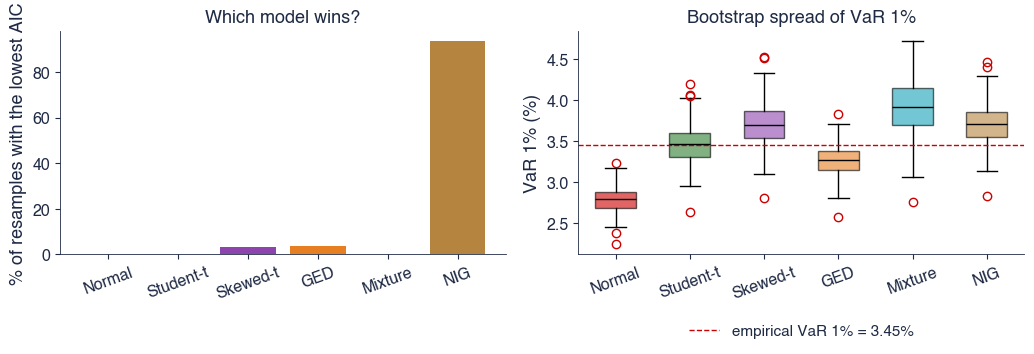

In [39]:
model_uncertainty('sp500', save=False)

In [40]:
pd.DataFrame(averaged_var(fits, tails)).T.round(2)

,avg,min_heavy,max_heavy,normal,emp
bet,4.11,3.74,4.94,3.19,4.13
sp500,3.72,3.27,4.54,2.80,3.45
dax,4.24,3.77,5.01,3.25,4.16
btc,9.85,9.85,14.26,7.99,10.51
tlv,4.62,4.49,5.41,4.01,5.10
snp,4.25,4.16,4.70,3.70,4.29
brd,4.33,4.18,4.74,3.81,4.50


## 9. AI for scientific discovery: does NIG still win after removing volatility clustering?

- Open question: which candidate fits returns divided by a volatility forecast best?
- Starter code: divide the S&P 500 returns by the EMA volatility (λ = 0.96, previous 250 days only), refit five models and compare the Akaike weights with those of the raw returns.
- Check before trusting any answer, yours or an AI's: no look-ahead in the volatility, the same sample for all models, the parameterisation of each law.

In [41]:
r = returns('sp500').values / 100
_, ema = var_rma_ema(r)
z = r[250:] / (ema / stats.norm.ppf(0.01))
res = {m: fit_model(m, z) for m in ['Normal', 'Student-t', 'Skewed-t', 'GED', 'NIG']}
aic = {m: 2 * K[m] - 2 * p['loglik'] for m, p in res.items()}
pd.Series({m: a - min(aic.values()) for m, a in aic.items()}).round(1)

Normal       502.9
Student-t     68.0
Skewed-t      24.1
GED           57.6
NIG            0.0
dtype: float64